# Продвинутый анализ моделей

## Импорт

Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, smape, mase

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import kpss
import pmdarima as pm

In [4]:
# def matplotlib2GOST:
plt.rcParams.update({
    # ШРИФТ
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 11,                      # ГОСТ: 10–12 pt

    # ОСИ И ПОДПИСИ
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,

    # РАЗМЕР ФИГУРЫ (A4, отчёты)
    # "figure.figsize": (6.5, 4.0),         # ~16.5 × 10 см
    "figure.figsize": (12, 3.0),         
    "figure.dpi": 150,
    "savefig.dpi": 300,

    # СОХРАНЕНИЕ
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,

    # ЛИНИИ И ОСИ
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "lines.linewidth": 1.5,
    "patch.linewidth": 1.0,

    # СЕТКА
    "axes.grid": True,                   # ГОСТ: обычно без сетки
    "axes.axisbelow": True,

    # TEX
    "text.usetex": False,
})


In [5]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter("ignore", FutureWarning)

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

In [6]:
from functools import partial

## Загрузка данных

Импорт данных аналогично предыдущего урока.

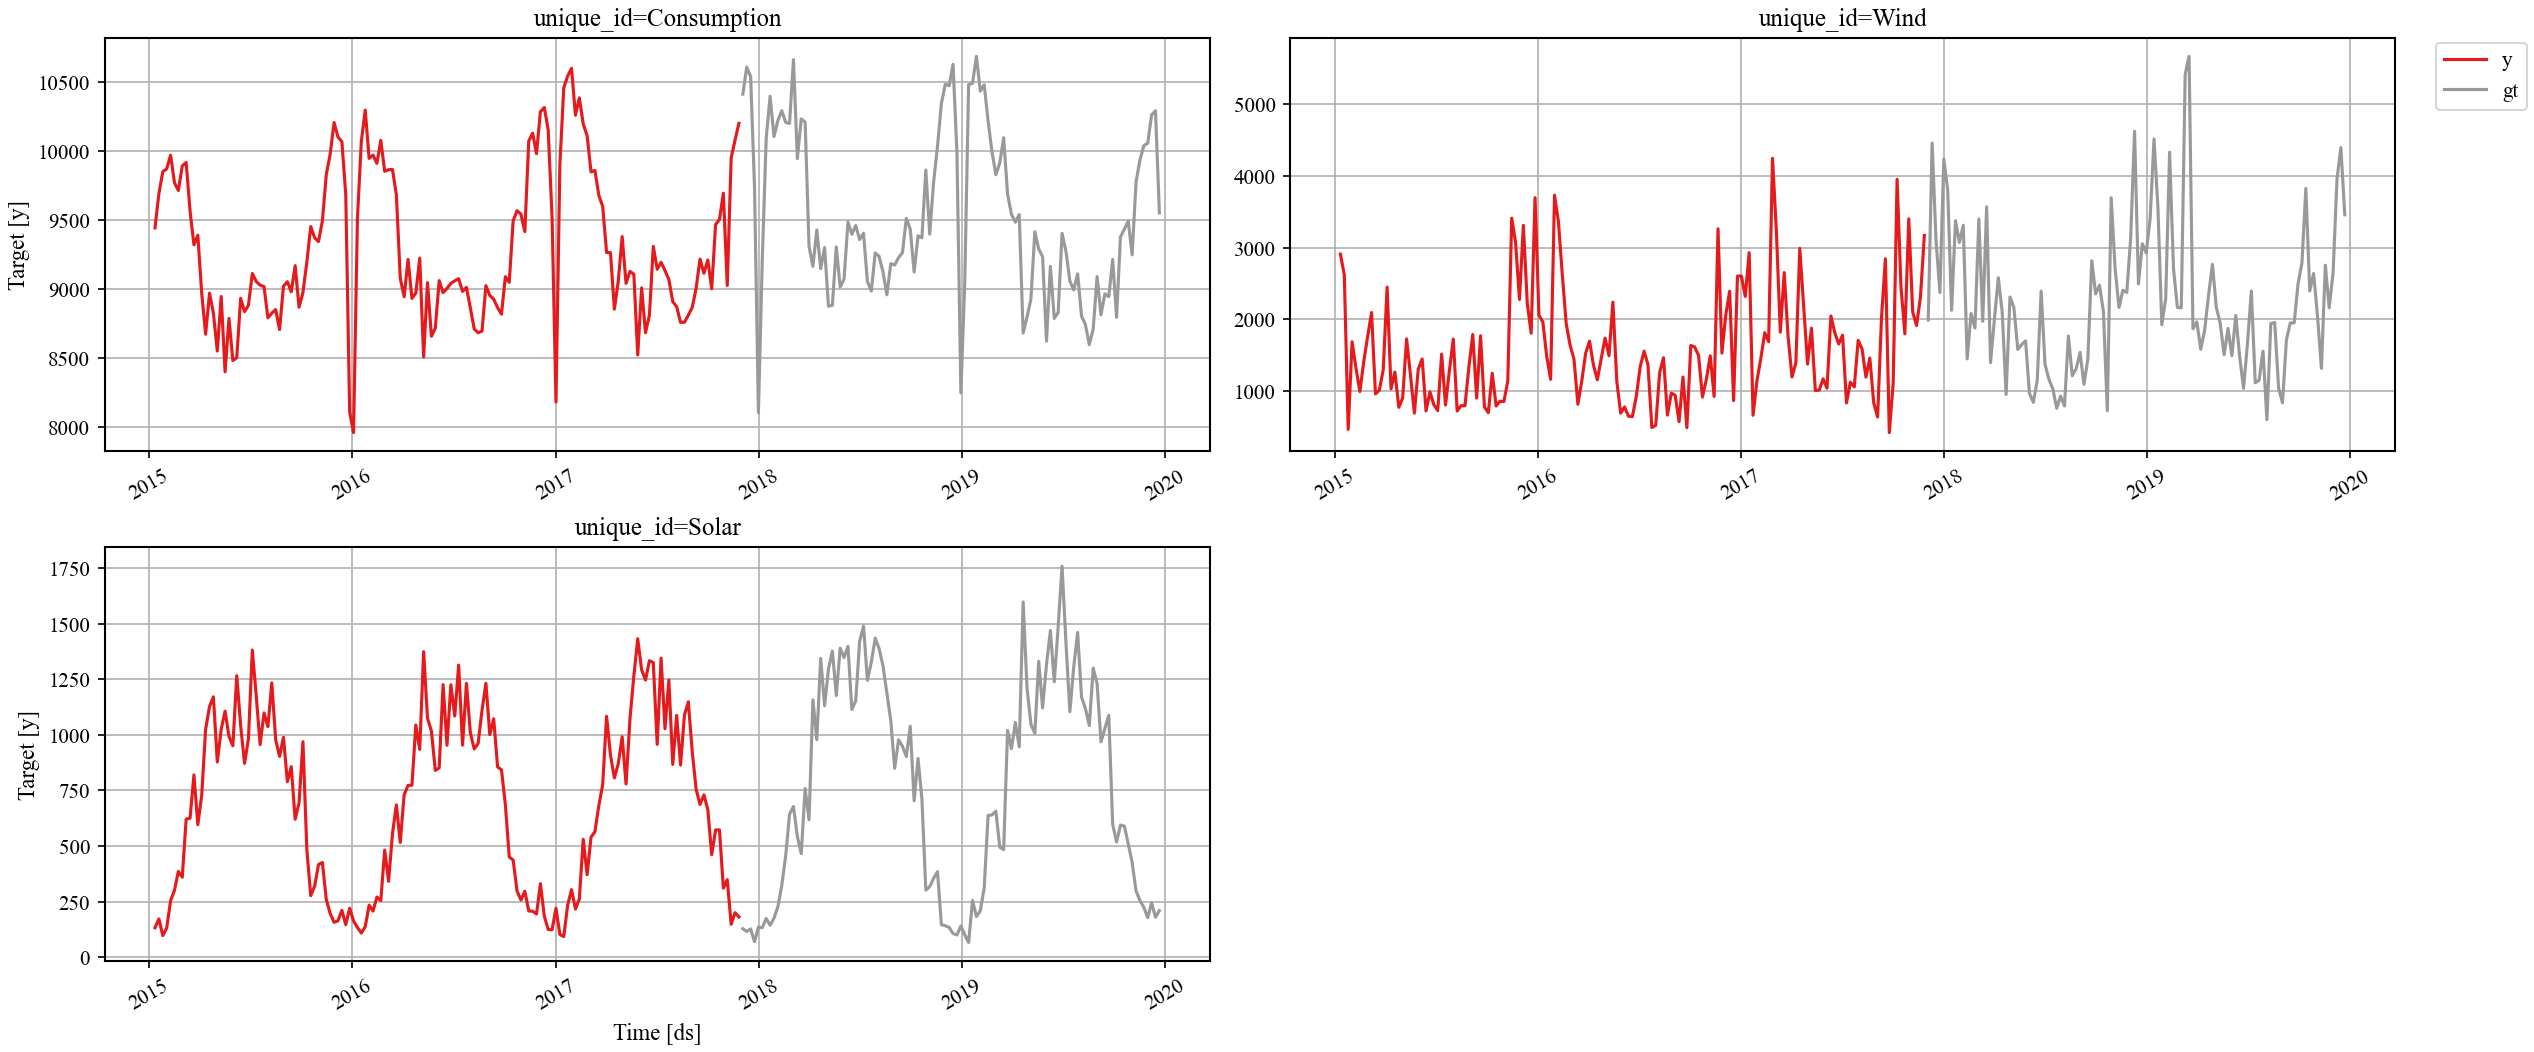

In [7]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']
y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

In [204]:
metric_map = {
    'mase': partial(mase, seasonality=SEASON),
    'rmse': rmse,
    'smape': smape
}
metrics = list(metric_map.values())
metric_names = list(metric_map.keys())

## Диагностика моделей временных рядов

### Методы диагностики моделей.
<!-- 1. Анализ метрик и сложности моделей
2. Анализ остатков моделей
3. Бектестинг и кросс-валидация моделей
4. Оценка интервального прогнозирования (разброс предсказания)
5. Анализ доверительности модели (надежность, устойчивость, интерпретируемость, конкретные ошибки и тд). -->


Существует как минимум четыре [источника неопределенности](https://nixtlaverse.nixtla.io/mlforecast/docs/tutorials/prediction_intervals_in_forecasting_models.html#importance-of-confidence-interval-prediction-in-time-series) при прогнозировании с помощью моделей временных рядов:
* Случайная составляющая ошибки (флуктуации);
* Ошибка оценки параметров (смещение);
* Ошибка связанная с выбором параметров модели на исторических данных (обобщающая способность, переобучение);
* Ошибка связанная с продолжением процесса генерирования исторических данных в будущем (воспроизводимость паттерном поведения ВР, дрифт данных).

<!-- - __Случайная составляющая ошибки (флуктуации)__ — это неустранимый шум, присущий самой природе данных. Даже при идеально подобранной модели будущие наблюдения будут отклоняться от прогноза из-за непредсказуемых внешних воздействий или внутренней стохастичности процесса.
- __Ошибка оценки параметров (смещение)__ — возникает потому, что параметры модели (например, коэффициенты регрессии или веса в дереве решений) оцениваются на конечной выборке. Эти оценки подвержены выборочной изменчивости: при другом наборе исторических данных они были бы иными, что привело бы к иному прогнозу.
- __Ошибка, связанная с выбором модели на исторических данных__ — отражает неопределённость в архитектуре или гиперпараметрах модели. Мы выбираем одну модель из множества возможных (ARIMA, XGBoost, Prophet и т.д.), но не знаем, действительно ли она наилучшим образом описывает истинный процесс. Эта неопределённость включает риски переобучения, недообучения и ограниченную обобщающую способность.
- __Ошибка, связанная с продолжением процесса генерирования данных в будущем (дрифт данных)__ — предполагает, что закономерности, наблюдаемые в прошлом, сохранятся в будущем. Однако в реальности могут произойти структурные изменения: смена режима работы системы, внешние шоки (экономические, климатические, технологические), изменение поведения пользователей. В таких случаях даже идеальная модель на исторических данных даёт смещённый прогноз. -->





- __Анализ метрик и сложности моделей__ <br>
Оценка качества прогноза с помощью количественных метрик (MAE, RMSE, MAPE) на тестовой выборке, а также учёт сложности модели через информационные критерии (AIC, BIC). Это позволяет найти баланс между точностью и переобучением.
- __Анализ остатков моделей__ <br>
Проверка свойств in-sample остатков: отсутствие автокорреляции (тест Льюнга–Бокса), стационарность, приближённая нормальность и отсутствие систематических паттернов. Хорошая модель должна оставлять «белый шум».
- __Бектестинг и кросс-валидация моделей__ <br>
Моделирование реальных условий прогнозирования с помощью пошагового сдвига окна обучения (rolling-origin evaluation). Позволяет оценить устойчивость модели во времени и избежать оптимизма, связанного с однократным разбиением на train/test.
- __Оценка интервального прогнозирования (разброс предсказания)__ <br>
Анализ прогнозных интервалов: проверка покрытия (coverage — доля истинных значений внутри интервала) и sharpness (средняя ширина интервала). Надёжная модель даёт узкие интервалы с заданным уровнем покрытия (например, 90%).
- __Анализ доверительности модели__ <br>
Комплексная оценка надёжности: устойчивость коэффициентов при изменении данных, интерпретируемость результатов (соответствие предметной области), анализ типичных ошибок (например, занижение пиков или реакция на экстремальные события). Это помогает понять, можно ли доверять модели в реальных условиях.

### Оценка остатков модели.

#### Визуализация остатков 

Важным аспектом анализа любых моделей (в том числе и ARIMA и ETS, Prophet  и других) является [анализ остатков предсказания моделей](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-diagnostics) (т.н. невязок или innovations - “innovation residuals”). Которые могут быть вычеслены как:
$$ e = y_t - \hat y_t$$


<blockquote>
    
- Остатки (__residuals__) — это общее понятие - разница между реальными наблюдениями и тем, что предсказала модель на обучающих данных.
- Инновации/невязка (__innovations__) — это то же самое, что остатки, но в контексте временных рядов: они показывают «новую информацию», которую модель не смогла предсказать на каждом шаге времени.
  
</blockquote>


В случае идеального прогноза остатки модели должны представлять собой белый шум. Это значит что такие остатки не объяснимы. 

Расмотрим пример простого алгоритма и его остатков.

In [52]:
mean_method = [SeasonalExponentialSmoothingOptimized(SEASON),
               HoltWinters(season_length=SEASON, error_type="A", alias="HW_Add"),
              ]

In [63]:
sf = StatsForecast(models=mean_method, freq=FREQ)
sf.forecast(h=FH, df=df_train, fitted=True)
fitted_values = sf.forecast_fitted_values()

model_names = [getattr(model, 'alias', type(model).__name__) for model in sf.models]
for col in model_names:
    fitted_values[f"resid_{col}"] = fitted_values["y"] - fitted_values[col].values

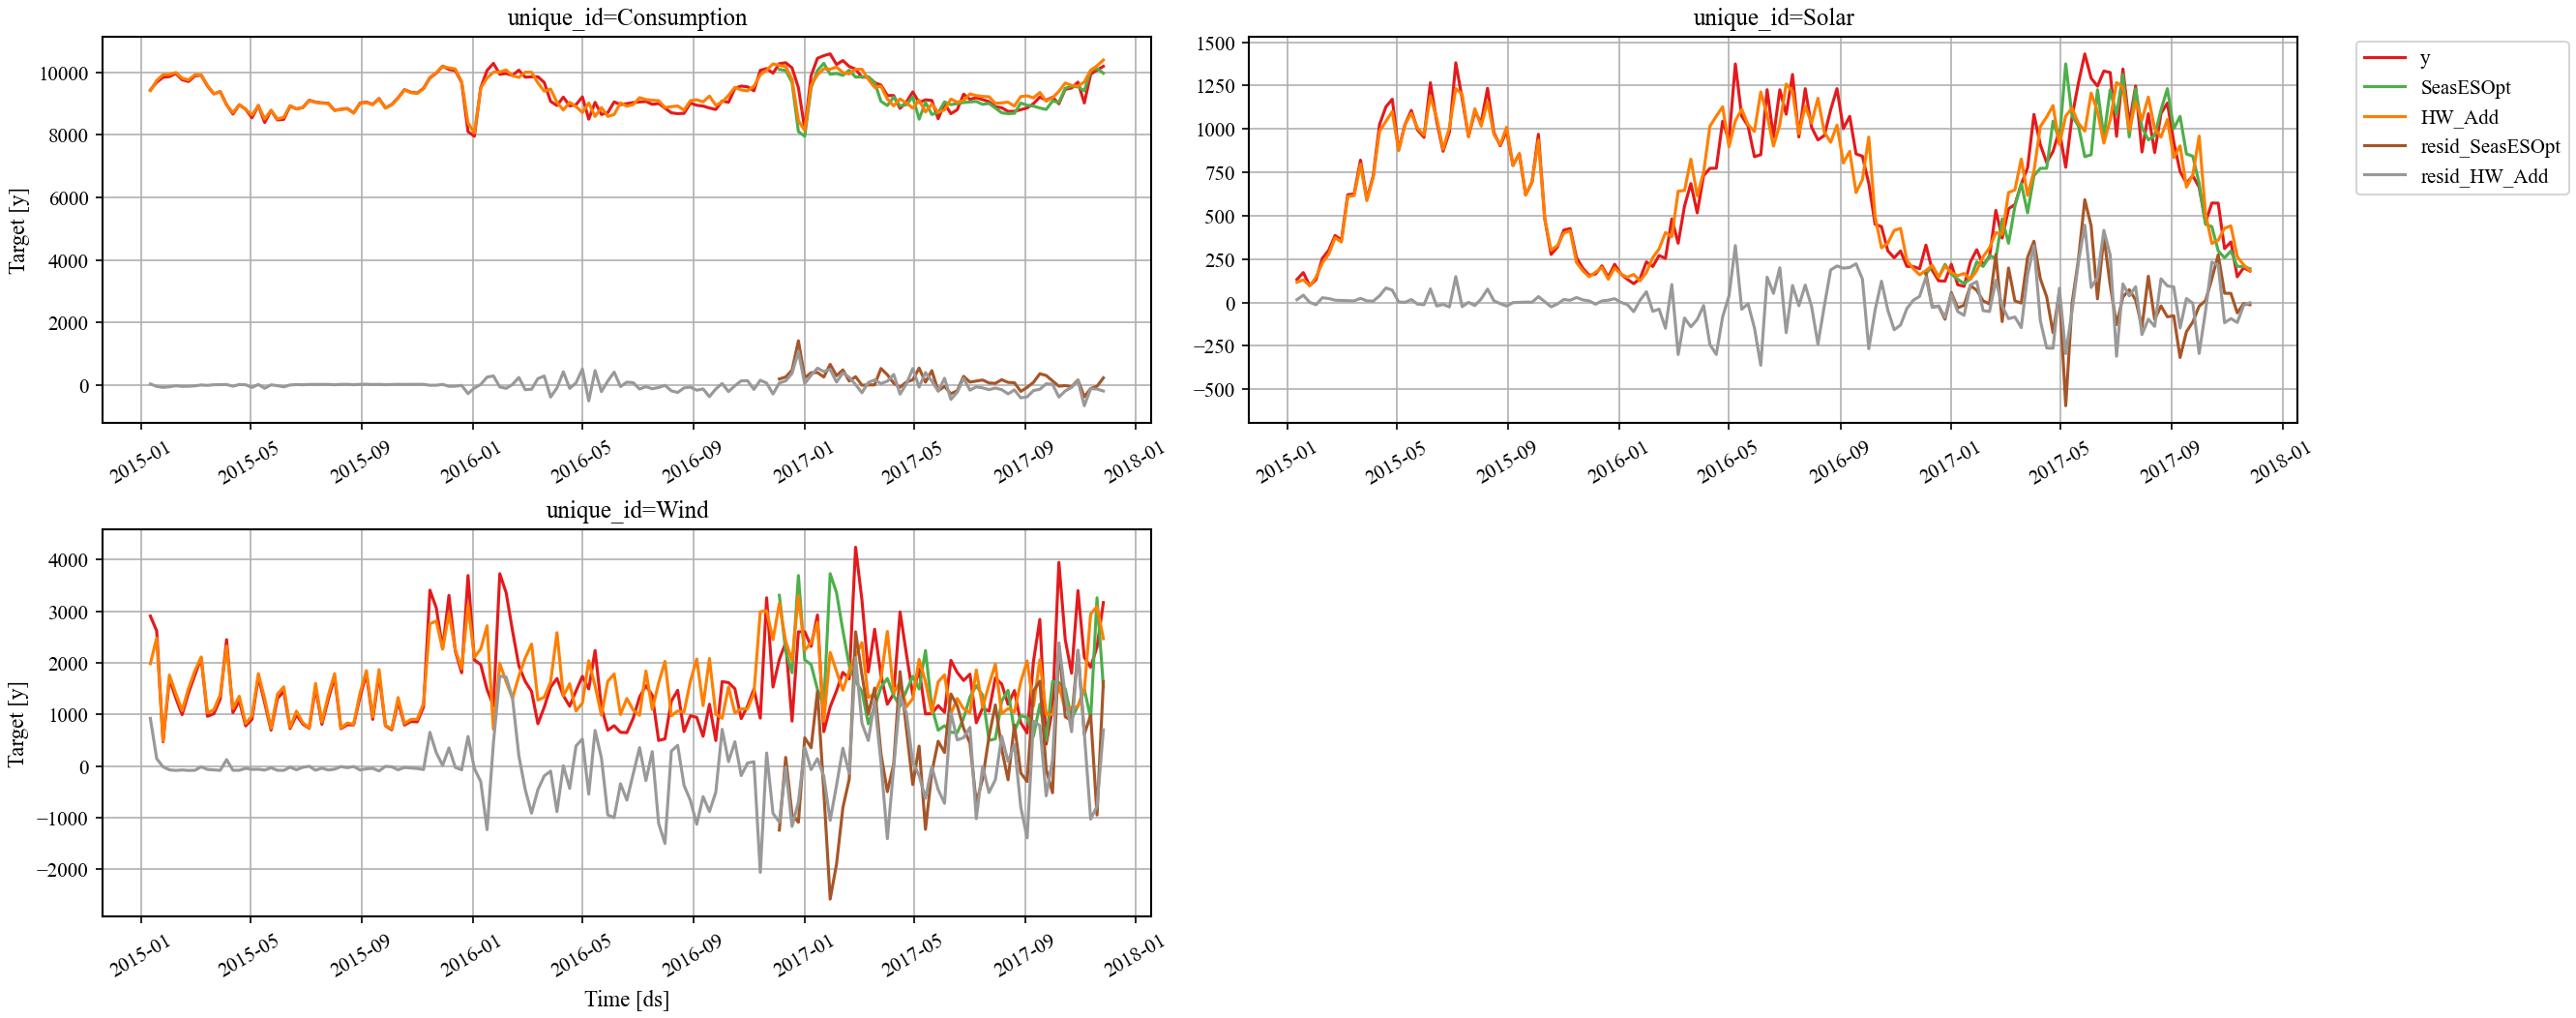

In [64]:

plot_series(forecasts_df = fitted_values, palette='Set1')

Видно, что каждой модели остаток значительно отличается от белого шума. Это означает, что остаток информативен (содержит информацию, не описанную моделью).


#### Диагностика остатков

На самом деле диагонстика остатков часто строится [по известному алгоритму](https://otexts.com/fpppy/nbs/05-toolbox.html#example-forecasting-google-daily-closing-stock-prices).

Для каждого ВР построим
1. __Остатки во времени__ (график в левом верхнем углу).
   - График показывает наличие тренда и сезонности в остатках, а также гетеросекдостичность разброса (шумов).
   - В название также показен результат теста __KPSS__, показывающий нестационарность данных по отклонениям от уровня (если p-value > 0.05 - гипотеза о стационарности).
2. __ACF__ (автокорреляционная функция) — график в правом верхнем углу.
   - Тут проверяется соотвествие остатков белому шуму и стационарность остатков. В иделае ACF должна иметь только нулевой лаг выше доверительного интервала.
   - В название графика  ACF также указается значение __теста  Льюнга–Бокса__. Если p-value теста Льюнга–Бокса > 0.05 (указано в заголовке) → автокорреляции нет (белый шум).
3. __Гистограмма остатков__ — график в левом нижнем углу.
   - Тут рассматривается на сколько гистограмма похоже на нормальное распределение, есть ли выбросы и тд.
   - Если есть сильный перекос → модель систематически завышает или занижает.
   - Если есть тяжелые хвосты - много выбросов.
   - Если распределение сильно отличается от нормального - модель неадекватна.
   - В заголовке указано значение Breusch–Pagan теста p-value.
   - Если BP p-value< 0.05 Отвергаем H₀ → гетероскедастичность присутствует.
4. __Q-Q plot__ (квантиль-квантильный график) — график в правом нижнем углу
   - График показывает сравнение модели и нормального распределения. Известны Q-Q plot для некоторых типичных видов распределний.
   - Например, точки изгибаются вверх/вниз → тяжёлые хвосты или перекос.
   - В название указано  p-value теста Jarque–Bera. Если p-value > 0.05 нормальность не отвергается (p-value < 0.05 → остатки не нормальны).

__Примеры выводов__:
- Если все 4 графика «хорошие» - модель адекватна, остатки похожи на белый шум.
- Если ACF чистый, но остальное плохо - модель динамику ловит, но, например, плохо калибрована.
- Если ACF плохой - модель недообучена — нужно улучшать спецификацию (больше лагов, сезонность и т.д.).


In [80]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tsa.stattools import kpss
from scipy import stats
import statsmodels.api as sm
import warnings
import numpy as np

def plot_model_diagnostics(df_resid, resid_col="resid", title_suffix=""):
    uid = df_resid['unique_id'].iloc[0]
    resid = df_resid[resid_col].dropna()
    if len(resid) < 10:
        print(f"Пропущено: {uid} — недостаточно данных")
        return
    
    T = len(resid)
    lags = min(2 * SEASON, T // 5) if SEASON and SEASON > 1 else min(10, T // 5)
    lags = max(lags, 1)
    
    # Тесты
    lb_pval = acorr_ljungbox(resid, lags=lags, return_df=True)['lb_pvalue'].iloc[-1]
    jb_stat, jb_pval = stats.jarque_bera(resid)
    exog = sm.add_constant(range(len(resid)))
    _, bp_pval, _, _ = het_breuschpagan(resid, exog)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            kpss_stat, kpss_pval, _, _ = kpss(resid, regression='c', nlags='auto')
        except Exception:
            kpss_pval = np.nan

    fig, axes = plt.subplots(2, 2, figsize=(9, 6))
    fig.suptitle(f'Диагностика остатков: {uid} {title_suffix}', fontsize=12)

    # [0,0] — Остатки + KPSS
    kpss_txt = f"Residuals (KPSS p={kpss_pval:.3f})" if not np.isnan(kpss_pval) else "Residuals"
    axes[0, 0].plot(df_resid['ds'], df_resid[resid_col], linewidth=0.8)
    axes[0, 0].set_title(kpss_txt)
    axes[0, 0].set_ylabel('Остатки')
    axes[0, 0].grid(True, linestyle='--', alpha=0.5)

    # [0,1] — ACF + Ljung-Box
    plot_acf(resid, ax=axes[0, 1], zero=False, auto_ylims=True)
    axes[0, 1].set_title(f'ACF (Ljung-Box p={lb_pval:.3f})')

    # [1,0] — Гистограмма + Breusch-Pagan
    axes[1, 0].hist(resid, bins=15, edgecolor='k', alpha=0.7)
    axes[1, 0].set_xlabel('Остатки')
    axes[1, 0].set_ylabel('Частота')
    axes[1, 0].set_title(f"Histogram (BP p={bp_pval:.3f})")

    # [1,1] — Q-Q + Jarque-Bera
    stats.probplot(resid, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title(f'Q-Q (JB p={jb_pval:.3f})')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

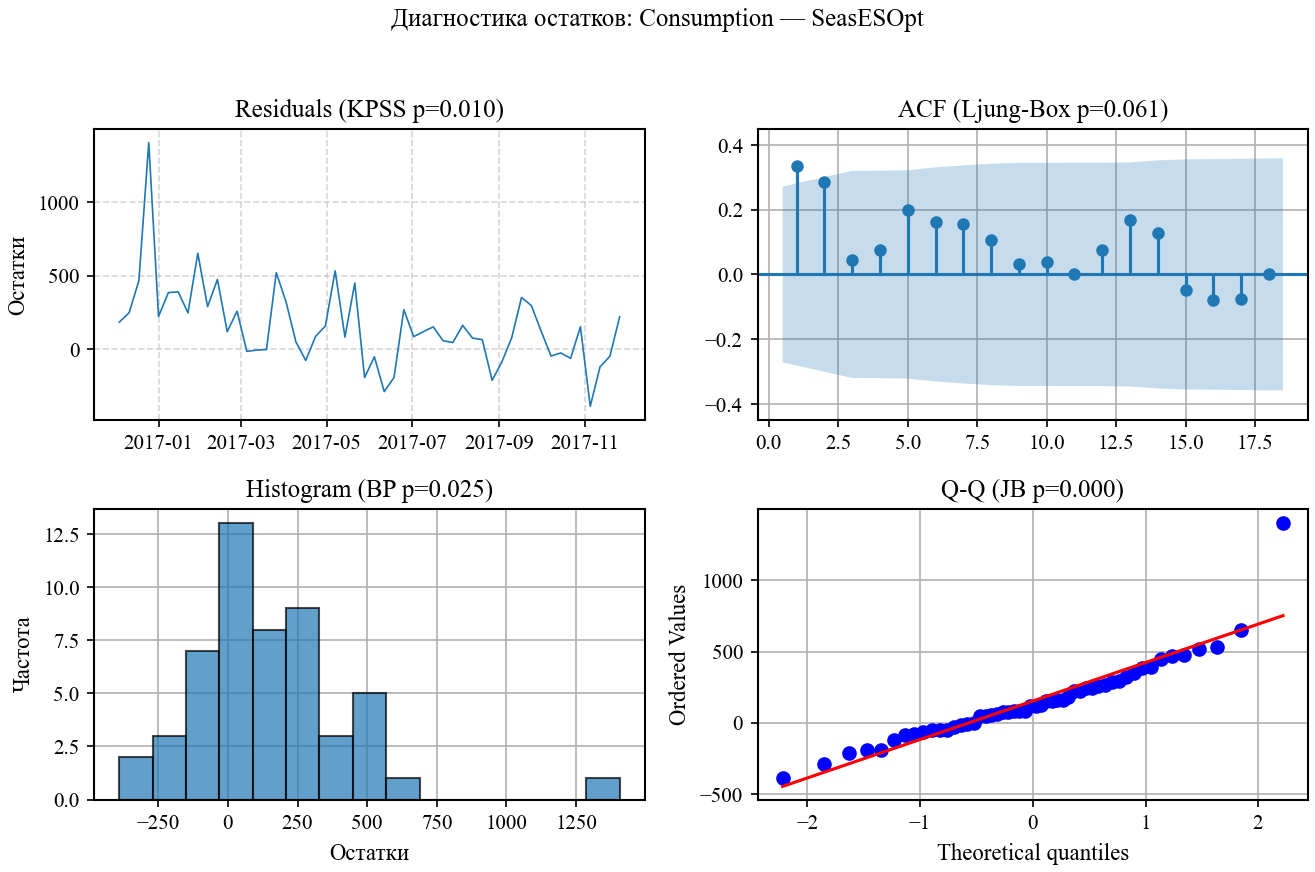

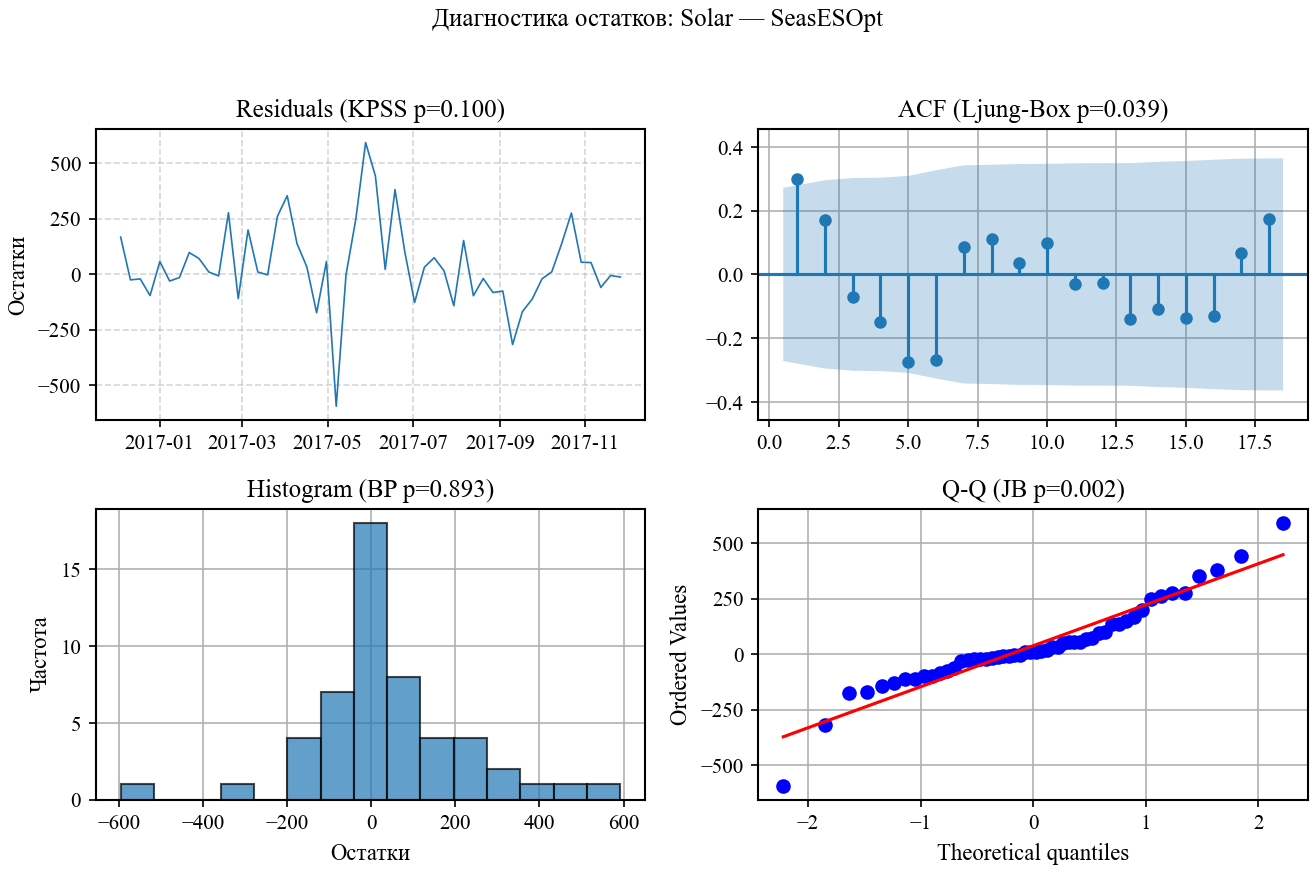

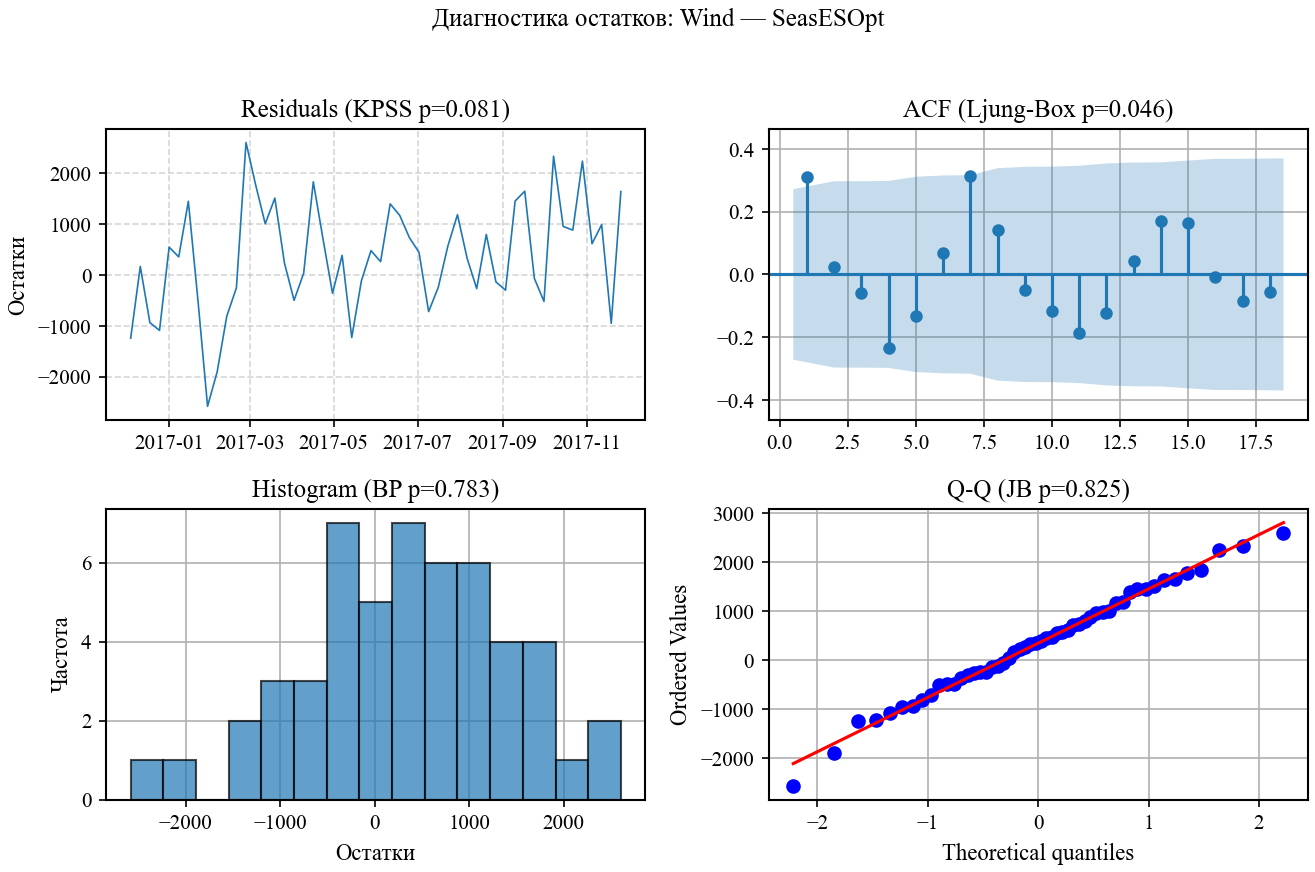

In [81]:
for uid in df_resid['unique_id'].unique():
    subset = fitted_values[df_resid['unique_id'] == uid]
    plot_model_diagnostics(subset, resid_col='resid_SeasESOpt', title_suffix='— SeasESOpt')

#### Упражнение
1. Провести оценку для базовых моделей ARIMA, Prophet, ETS, сравните модели и выберите лучшую 

## Вали модели


### Walk-forward validation

#### ExpandingWindowSplitter

Ранее валидация моделей проводилась путем одноразового деления ВР на последовательные участки тренировки и валидации. Однако в силу присущей ВР нестационарности поведения такой подходя может привести к слишьком не точным (как правило слишьком оптимистичным) результатам. 
Самый простой способ  повышения надежности  валидации моделей ВР - мы можем  разделить  набор данных несколько раз по аналогии с методом `k-folds`. Однако, в соответствии с особенностями временных рядов - временной связанностью метод`k-folds` должен [не нарушать принцип казуальности](https://forecastegy.com/posts/time-series-cross-validation-python/). Другими словами [выборка валидации должна следовать за тренировочными данными](https://otexts.com/fpp3/tscv.html). __Такой подход также известен как [<tt>backtesting/ walk-forward validation</tt>](https://joaquinamatrodrigo.github.io/skforecast/0.8.1/user_guides/backtesting.html)__.

>Напомним, результат [кросс-валидации](https://www.statology.org/k-fold-cross-validation/) по нескольким блокам более валиден [(менее смещен)](https://machinelearningmastery.com/k-fold-cross-validation/), нежели валидация одной [отложенной выборкой](https://scikit-learn.org/stable/modules/cross_validation.html).

>__Backtesting (ретроспективное тестирование)__ и __walk-forward validation  (пошаговая валидация)__ часто используются как синонимы, но в строгом смысле они отражают разные варианты  одного и того же принципа.
>
>__Walk-forward validation__ -  процедура при которой: начальное обучающее окно фиксируется (например, первые 365 дней),
модель тестируется на следующем коротком интервале (например, 7 дней), затем обучающее окно расширяется (или сдвигается), включая данные, использованные для теста, процесс повторяется до конца выборки.
>
>__Backtesting__ не имеет конкретного алгоритма , но часто преполагает проверку точности модели на последовательности интервалов без дообучения - то есть имитация работы модели в реальной среде. Ближе всего к этому определению подходит стратегия, когда окон тренировки выбирается один раз,а тест осуществляется на наборе последовательных окон.

В случае временного ряда кросс валидация может быть выполнена в скользящем окне по данным  [<tt>rolling backtest evaluation</tt>](https://docs.aws.amazon.com/whitepapers/latest/time-series-forecasting-principles-with-amazon-forecast/step-4-evaluate-predictors.html#prediction-quantiles-and-accuracy-metrics).
> [Приемущественно метода](https://mydata.ch/backtesting-in-time-series-forecasting-for-maximum-performance/)  бектеста скользящим окном следующие:
>* позволяет  быть уверенным, что  прогнозы точны и последовательны в течение длительного периода времени.
>* может помочь  найти и исправить "плавоющие" ошибки в модели данных. То есть редкие, но достаточно регулярные ошибки (неучтенную информоацию), которые можно участь в модели.
>* может помочь выявить недостающие внешние факторы в данных, которые помогут модели делать более точные прогнозы.
<!-- ✅It allows you to ensure that your forecasts are accurate and consistent over a long period of time

✅It can help you to find and correct errors in your models.

✅It can help you to identify missing external factors in your data that would help the model make better forecasts -->

>Напомним, что в прогнозировании временных рядов под <tt>бэктестингом</tt> понимается процесс проверки модели прогноза на исторических данных. Этот метод предполагает пошаговое движение назад во времени, чтобы оценить, насколько хорошо показала бы себя модель, если бы она использовалась для прогнозирования в этот период времени.

С технической точки зрения идея тут [заключается следующем](https://joaquinamatrodrigo.github.io/skforecast/0.11.0/user_guides/backtesting.html). Задается некторая ширина окна временного ряда. Заданное окно скользит по временному ряду с начального положения, например, таким образом, что все данные перед ним являются тренировочными, а после тестовыми. Могут быть и [другие стратегии](https://www.sktime.net/en/stable/examples/forecasting/window_splitters.html), например, что только лишь выборка заданного размера перед окном является тренировочной. Такие стратегии называются `ExpandingWindowSplitter` и `SlidingWindowSplitter` соответственно.

Для использования данных стратегий рекомендуем задавать оконо списком чисел вместо дат. Попробуем для начала визуализировать `ExpandingWindowSplitter`

> Отметим что по своей идеалогии данная процедура аналогична тому, что модель бы тестировалась на поступающих данных в соответствующих рабочих режмах. При этом целью такого тестирования бы была оценка работоспособности модели. Другими словами тестирование гипотезы о необходимости сменить модель (например переобучить). Такая процедура называется [<tt>walk-forward validation</tt>](https://machinelearningmastery.com/backtest-machine-learning-models-time-series-forecasting/).

<!-- In time series forecasting, backtesting refers to the process of validating a predictive model using historical data. The technique involves moving backwards in time, step-by-step, to assess how well a model would have performed if it had been used to make predictions during that time period. -->

Используем метод [`cross_validation`](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/cross_validation.html) для обучения и оценки моделей. В данном случае это будет аналог `ExtendedWindowCV` рассмотренного ранее. Здадим следующие парамерты:
* `df`: Получает обучающие данные 
* `h`: Горизонт прогнозирования 
* `n_windows`: Количество слайдов, которые мы хотим спрогнозировать.
* `step_size`: шаг между окнами
* `refit=True`: Для каждого окна прогноз будет обновлен заново.

<!-- Также можно задать имена столбцов временного ряда: 
+ `id_col`:Столбец, идентифицирующий каждый ВР (по умолчанию уникальный_ид) 
+ `time_col`: Столбец, идентифицирующий каждый временной шаг, его значения могут быть временными метками или целыми числами (По умолчанию `ds`) 
+ `target_col`:Столбец, содержащий целевой ВР (По умолчанию `y`) -->

Отметим что в полеченных результатах будут показаны:
* `cutoff`: последняя временная метка для каждого из `n_windows`.
* `models`: набор столбцов для моделей

> Напомним, что `ExtendedWindowCV` может быть [отображен как](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/cross_validation.html):
<img src="https://raw.githubusercontent.com/Nixtla/statsforecast/main/nbs/imgs/ChainedWindows.gif" width="500px">

In [ ]:
models = [
    SeasonalExponentialSmoothingOptimized(SEASON),
    HoltWinters(season_length=SEASON, error_type="A", alias="HW_Add")
]
model_names = [getattr(m, 'alias', type(m).__name__) for m in models]

In [170]:
sf = StatsForecast(models=models, freq=FREQ) 

cv_df = sf.cross_validation(
    df=panel_df,
    h=FH//2,
    n_windows=4,
    step_size=FH//2, 
    # refit=True,
)
cv_df.head()

,unique_id,ds,cutoff,y,SeasESOpt,HW_Add
0,Consumption,2015-11-08,2015-11-01,9491.391,NaN,9421.084742
1,Consumption,2015-11-15,2015-11-01,9826.524,NaN,9459.113070
2,Consumption,2015-11-22,2015-11-01,9976.205,NaN,9489.535733
3,Consumption,2015-11-29,2015-11-01,10203.088,NaN,9513.873863
4,Consumption,2015-12-06,2015-11-01,10097.922,NaN,9533.344367


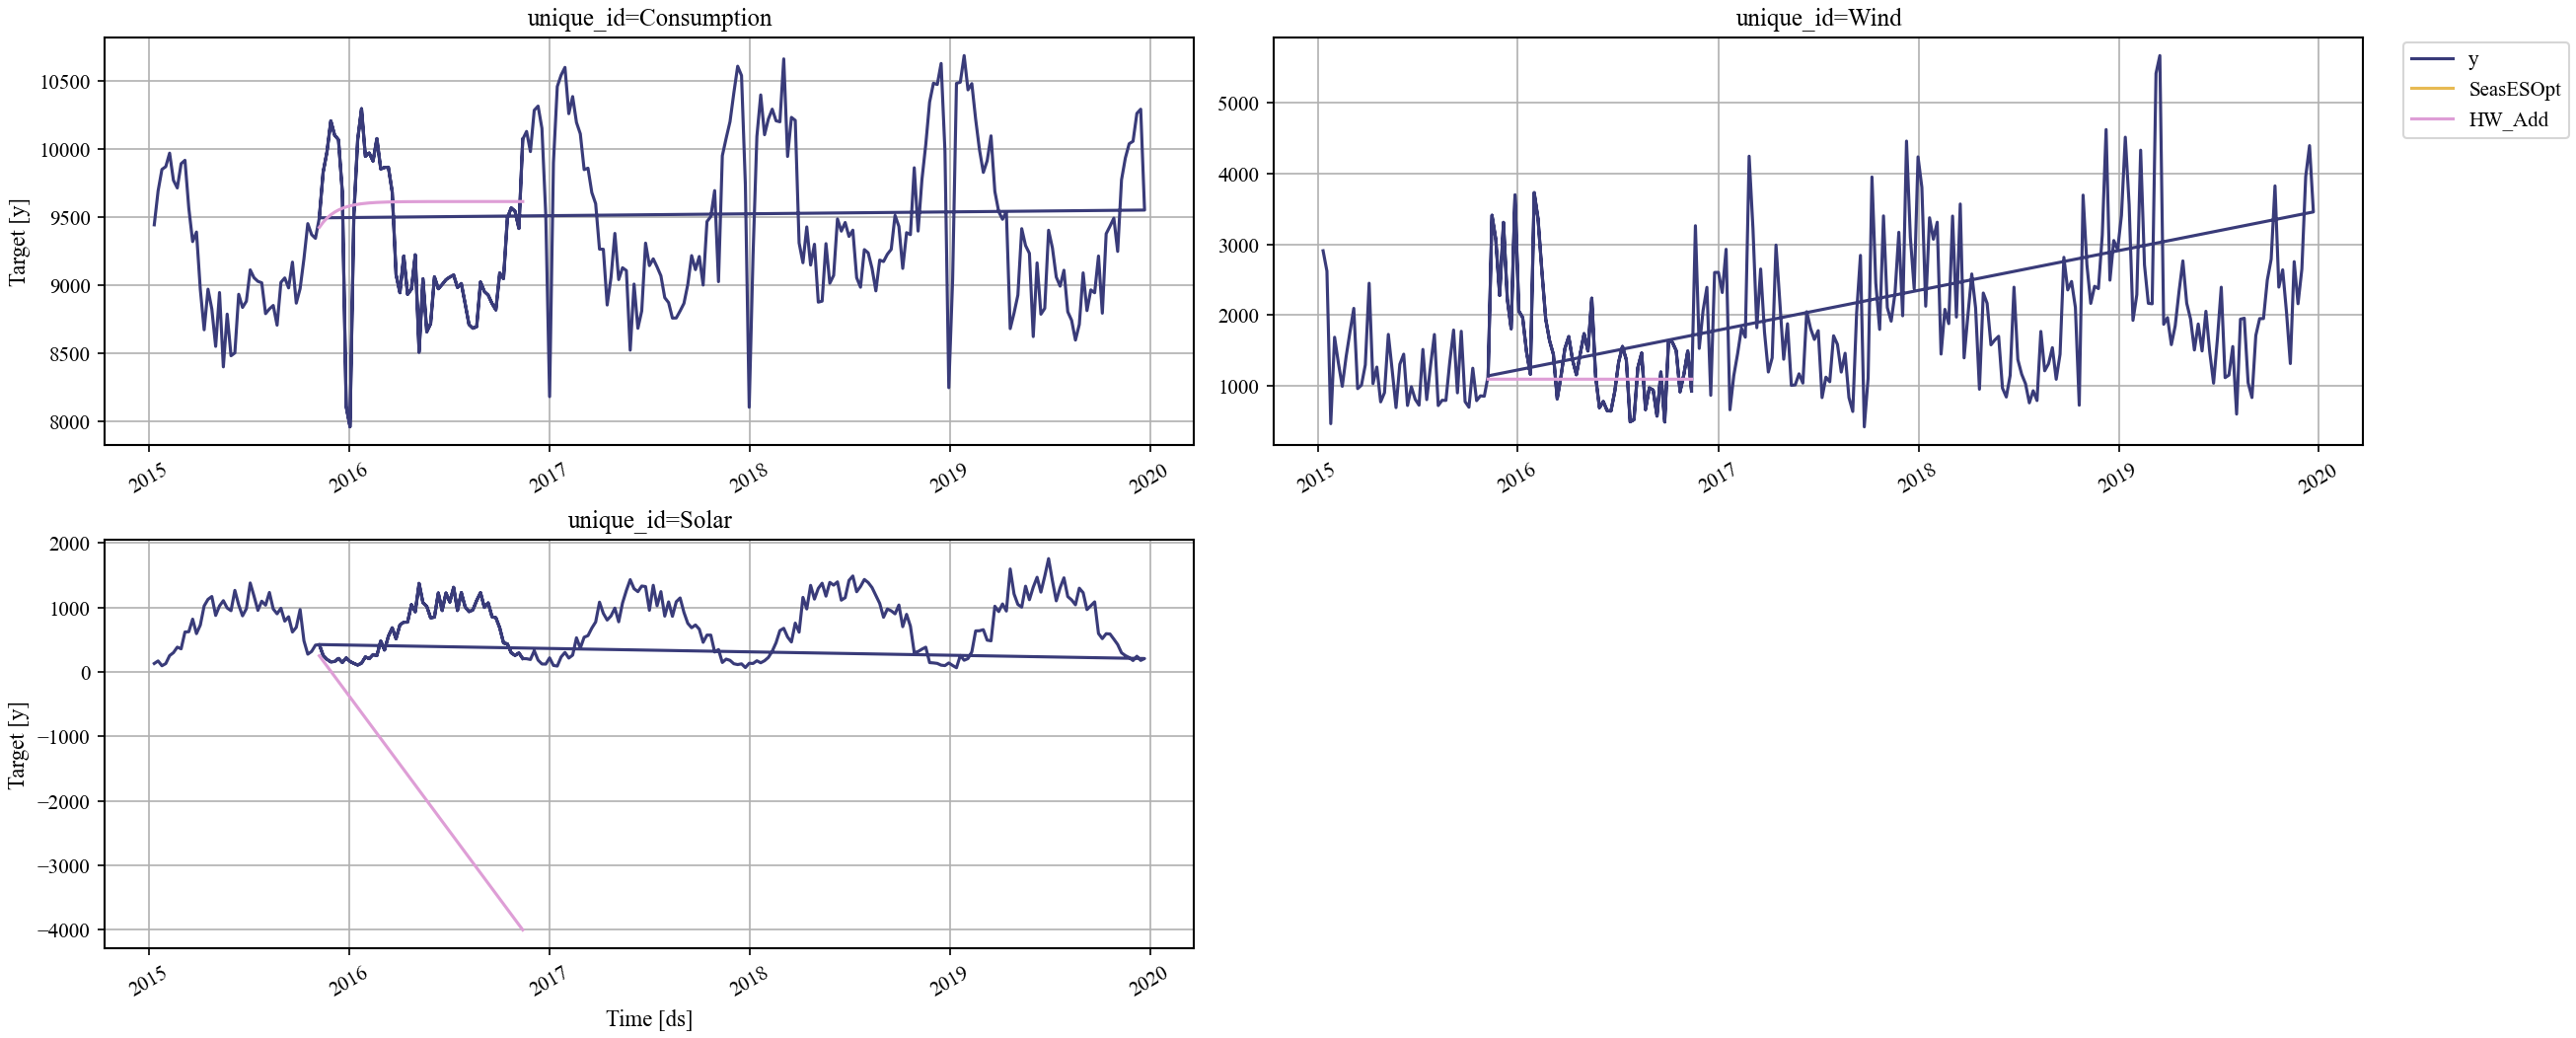

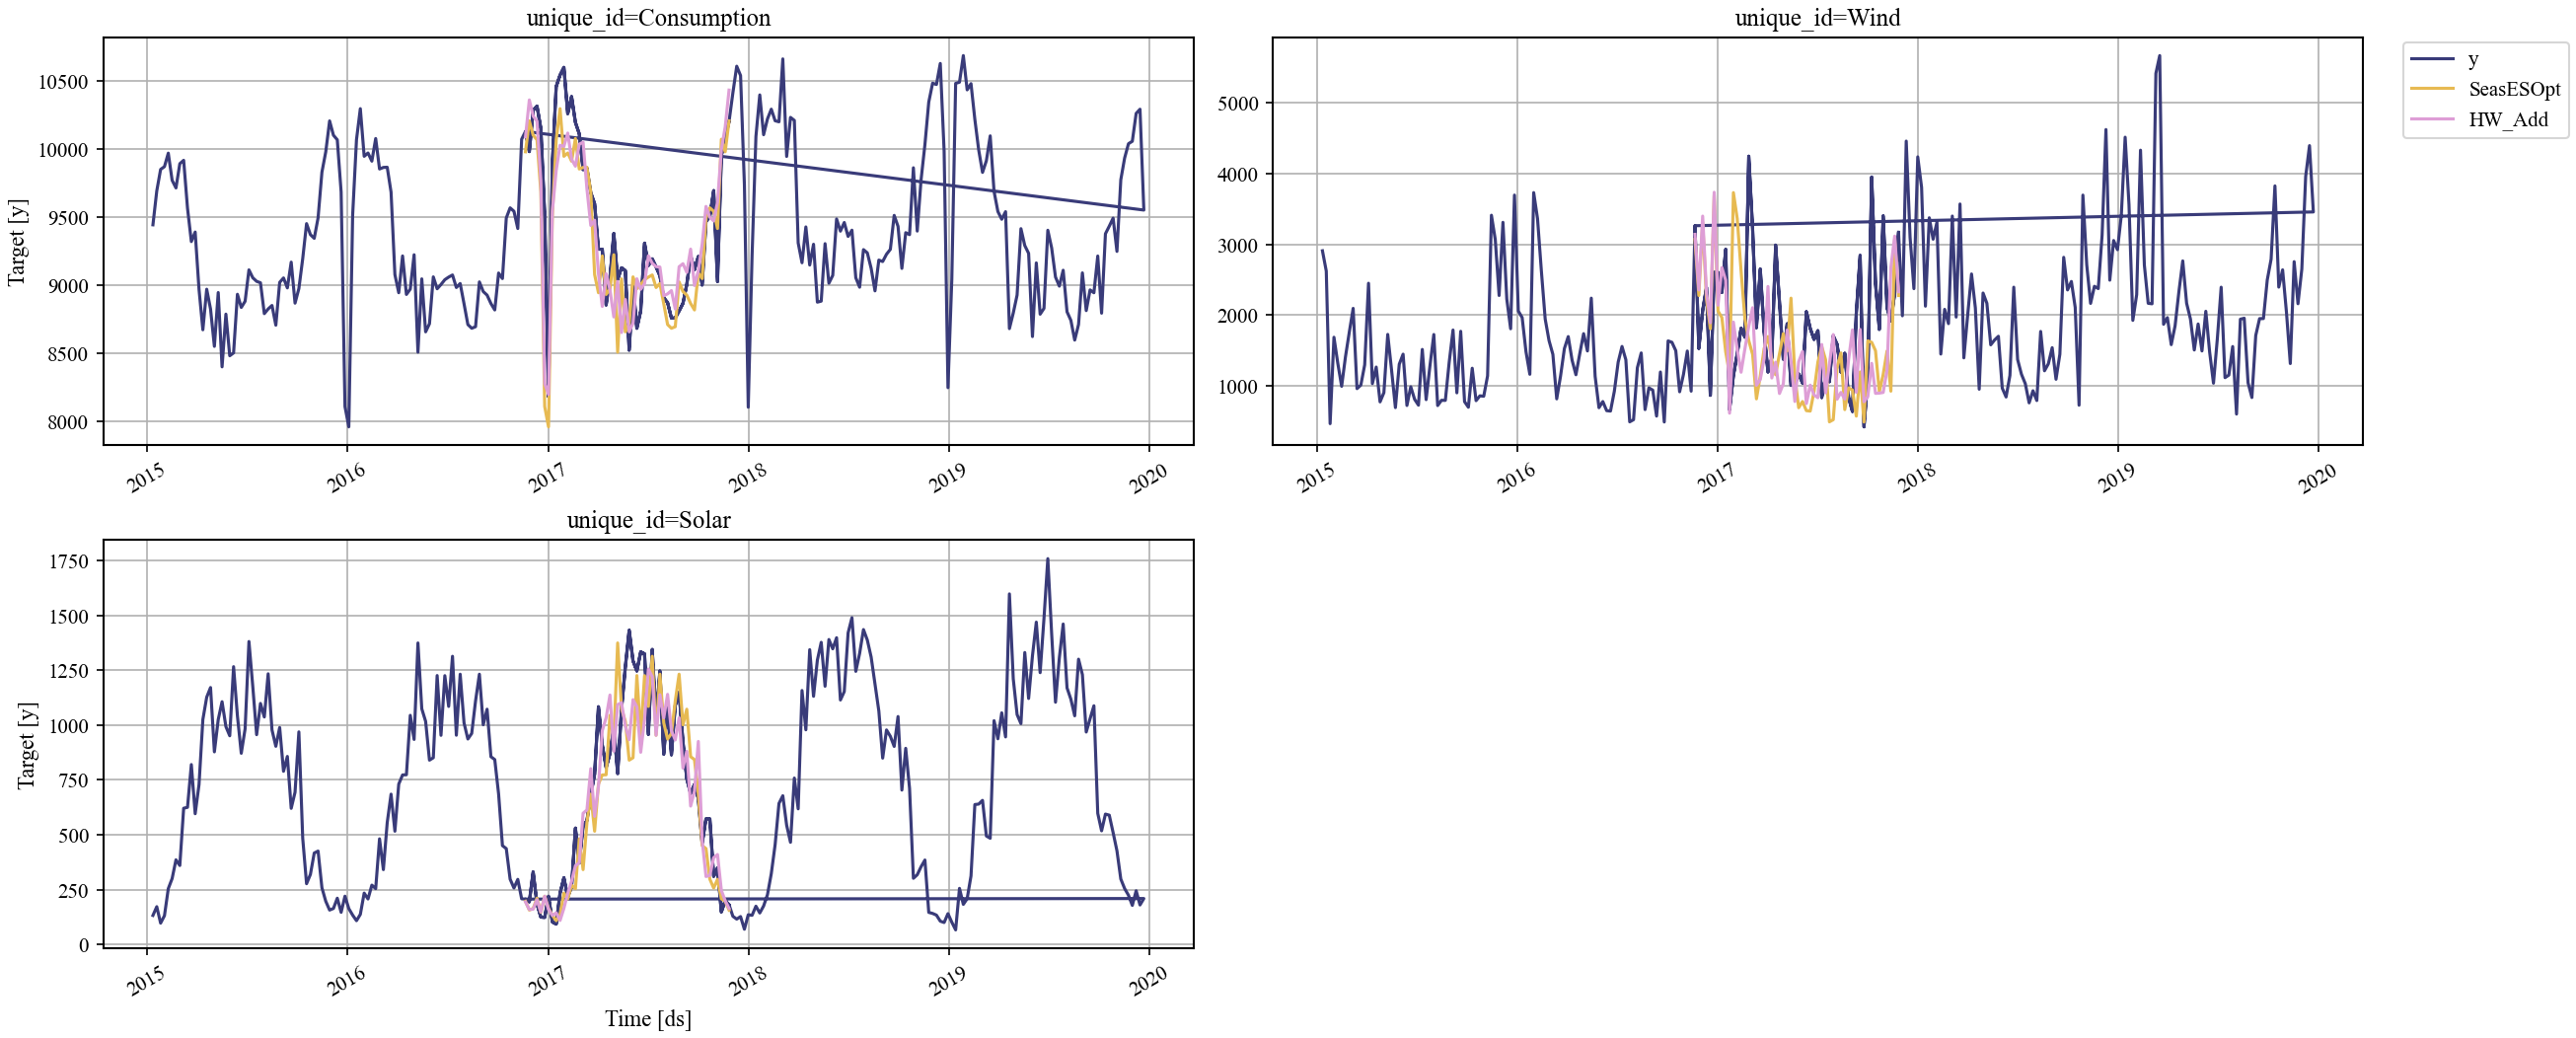

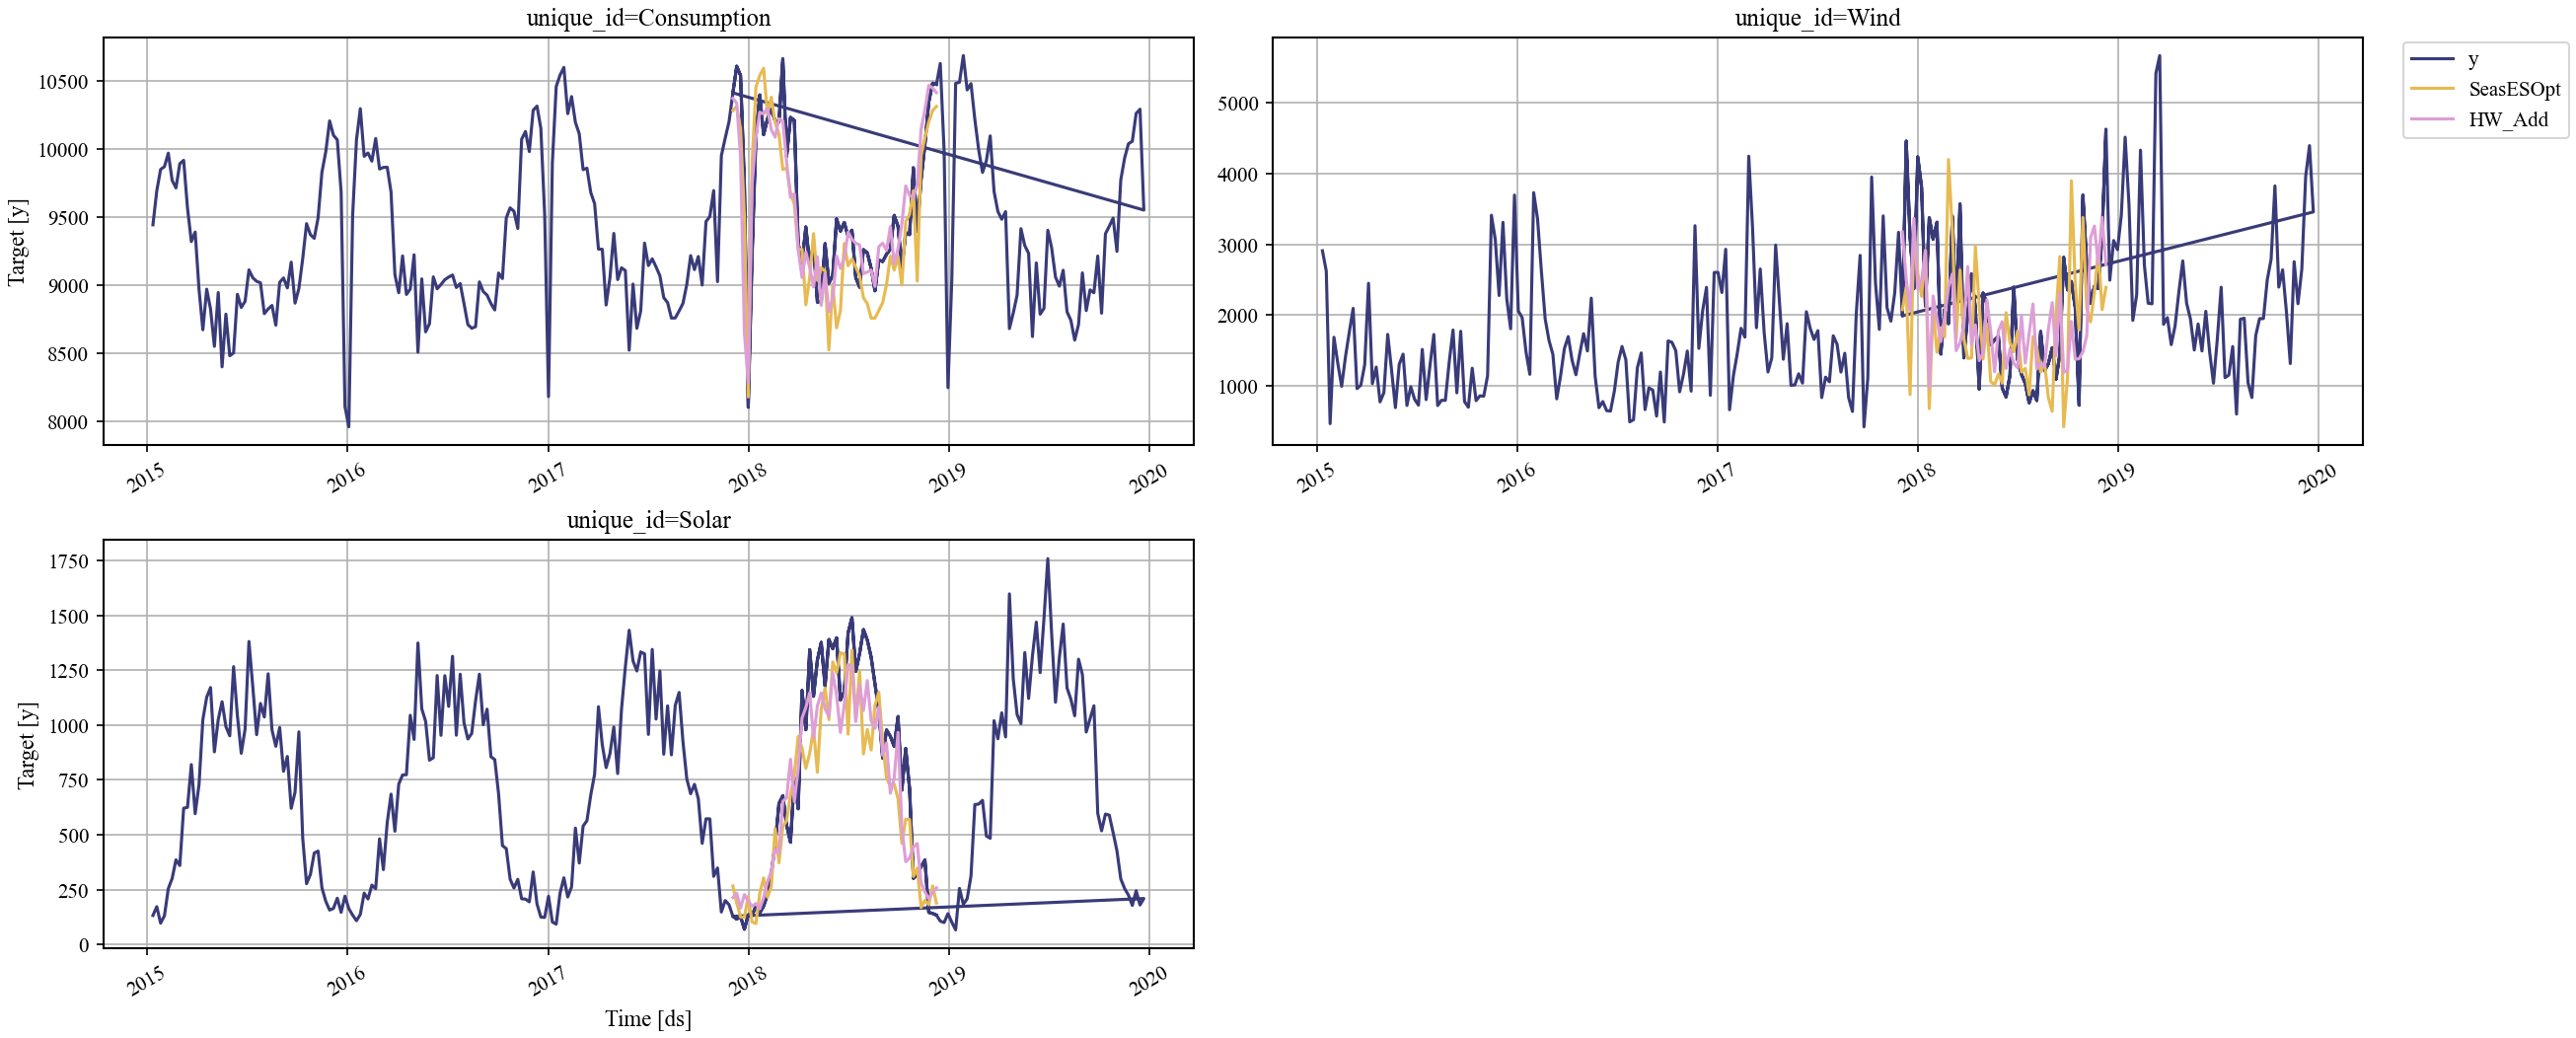

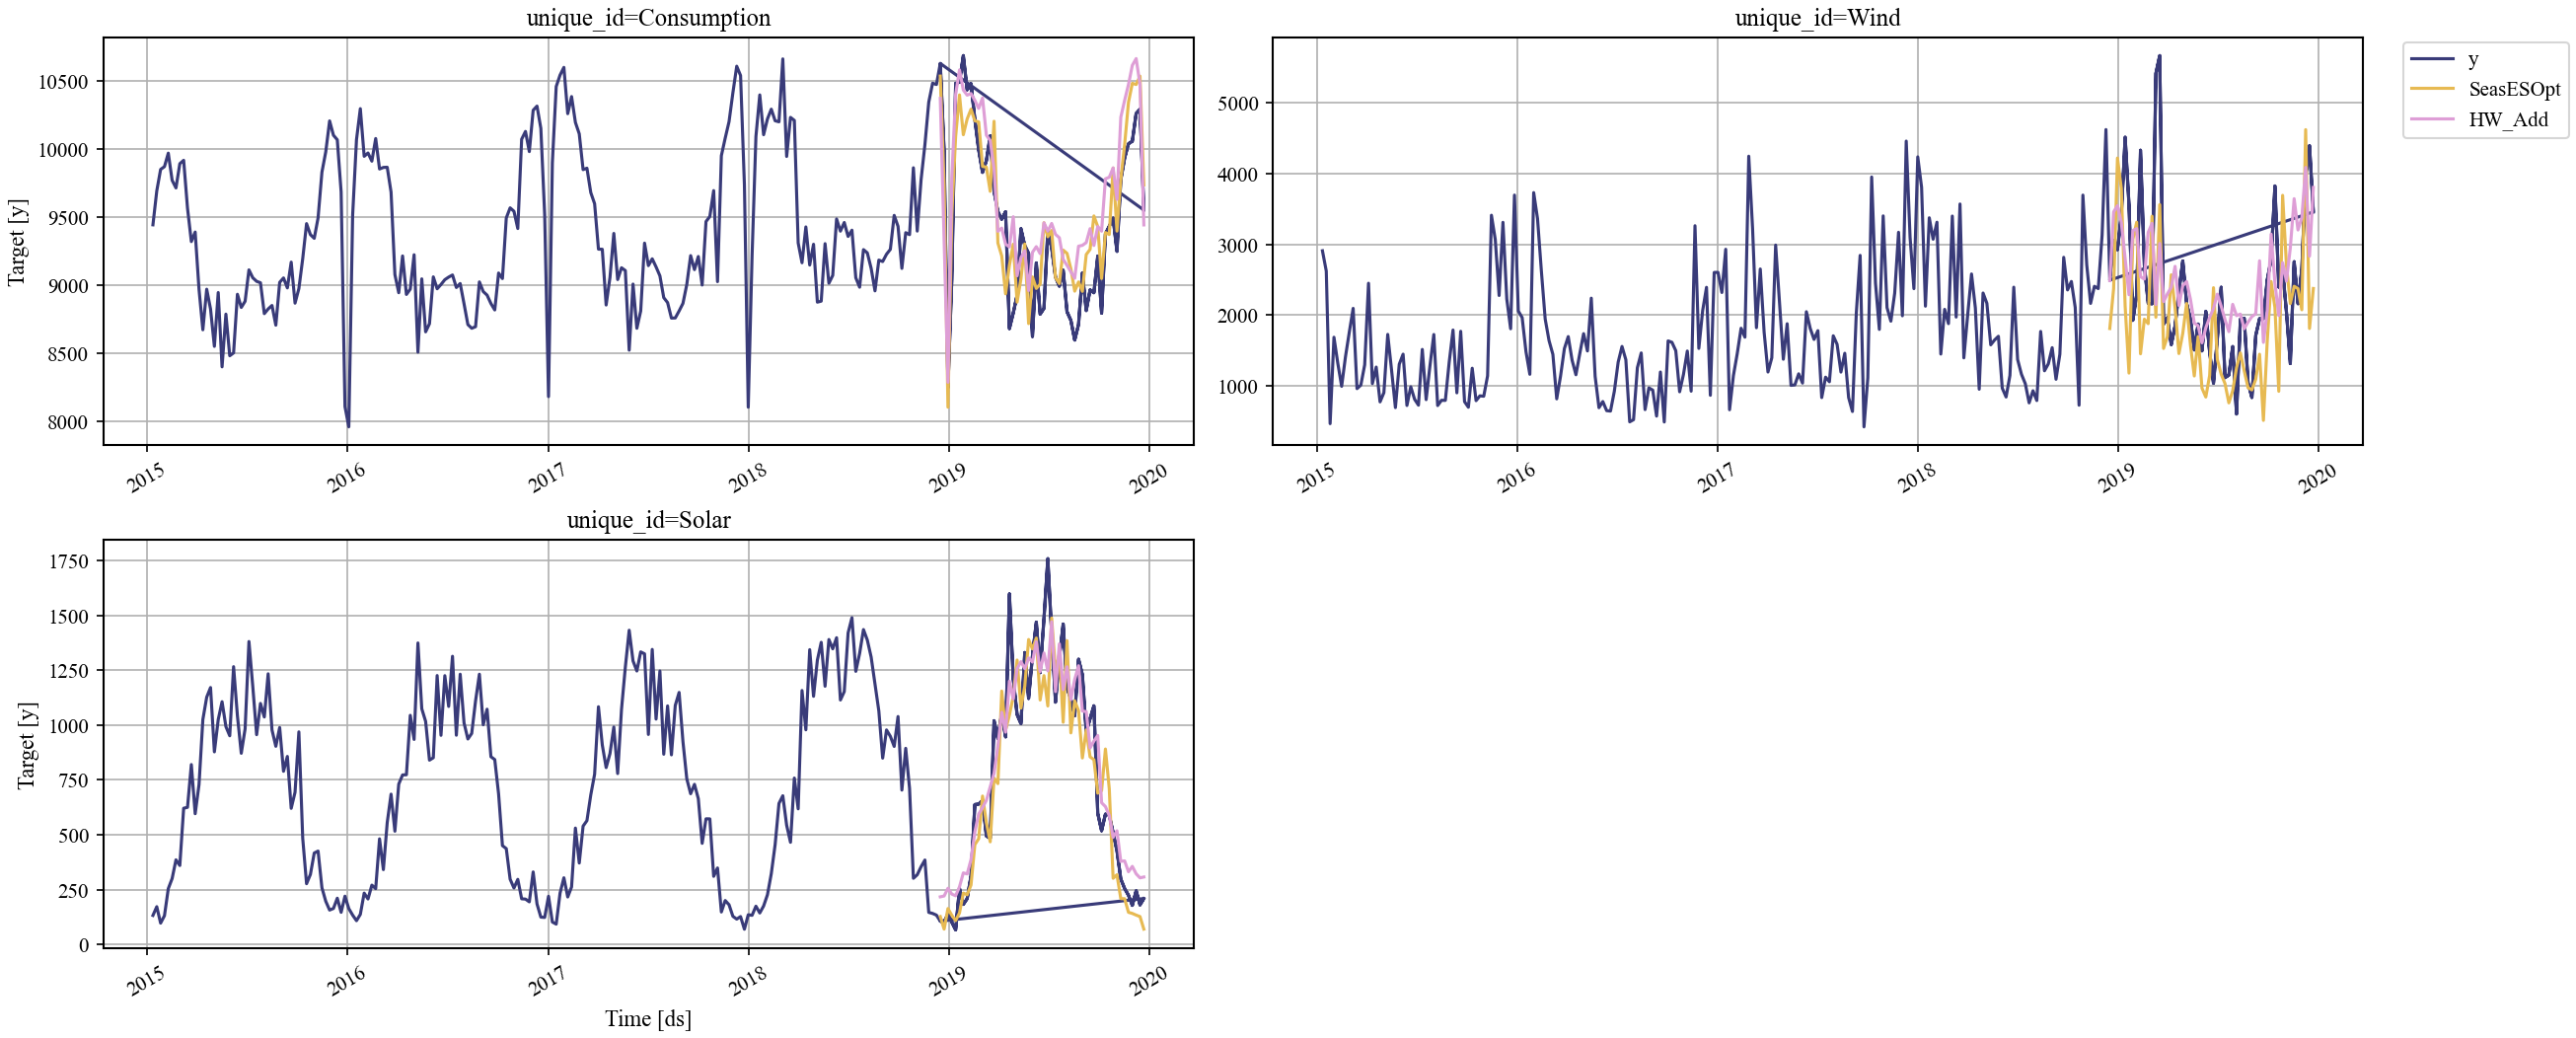

In [179]:
# cv_df.rename(columns = {'y' : 'actual'}, inplace = True) # rename actual values

cutoff = cv_df['cutoff'].unique()

for k in range(len(cutoff)):
    cv = cv_df[cv_df['cutoff'] == cutoff[k]]
    display(StatsForecast.plot(panel_df, cv.loc[:, cv.columns != 'cutoff']))

Проведем оценку средей точности для обоих методов.

In [172]:
def evaluate_cv(crossvalidation_df, metrics, model_names, target_col='y'):
    evaluations = []
    for c in crossvalidation_df['cutoff'].unique():
        df_cv = crossvalidation_df.query('cutoff == @c')
        evaluation = evaluate(
            df=df_cv,
            metrics=metrics,
            models=model_names,
            target_col=target_col
        )
        # УДАЛЯЕМ unique_id СРАЗУ — чтобы не мешался
        evaluation = evaluation.drop(columns=['unique_id'], errors='ignore')
        evaluations.append(evaluation)
    
    # Теперь все колонки — числовые
    evaluations = pd.concat(evaluations, ignore_index=True)
    evaluations = evaluations.groupby('metric').mean()
    return evaluations.style.background_gradient(cmap='RdYlGn_r', axis=1)

# 5. Запуск
result = evaluate_cv(
    crossvalidation_df=cv_df,
    metrics=[smape, mae, rmse],  # или любые другие из statsforecast.utils
    model_names=model_names
)

result

,SeasESOpt,HW_Add
metric,,
mae,424.178376,601.507337
rmse,546.015989,745.921824
smape,0.090337,0.181911


Попробуем визулизировать окона, которые мы получили

In [304]:
def plot_cv_windows(df, unique_id, cutoffs, h, title="CV Windows"):

    fig, ax = plt.subplots(figsize=(10, 2))
    # test_ends = cutoffs + pd.to_timedelta(h, unit=)
    for i, cutoff in enumerate(cutoffs):
        y_level = i + 1
        test_end = pd.to_datetime(cutoff) + pd.Timedelta(weeks=h)
        ax.plot([df['ds'].min(), cutoff], [y_level, y_level],  color='blue', linewidth=2)
        ax.plot([cutoff, test_end], [y_level, y_level],  color='red', linestyle='--', linewidth=2)
        ax.scatter([cutoff], [y_level], color='black', s=20)
        ax.scatter([test_end], [y_level], color='black', s=20)
    ax.set_yticks(range(1, len(cutoffs) + 1))
    ax.set_yticklabels([f"Окно {i+1}" for i in range(len(cutoffs))])
    ax.set_title(title)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout();     plt.show()

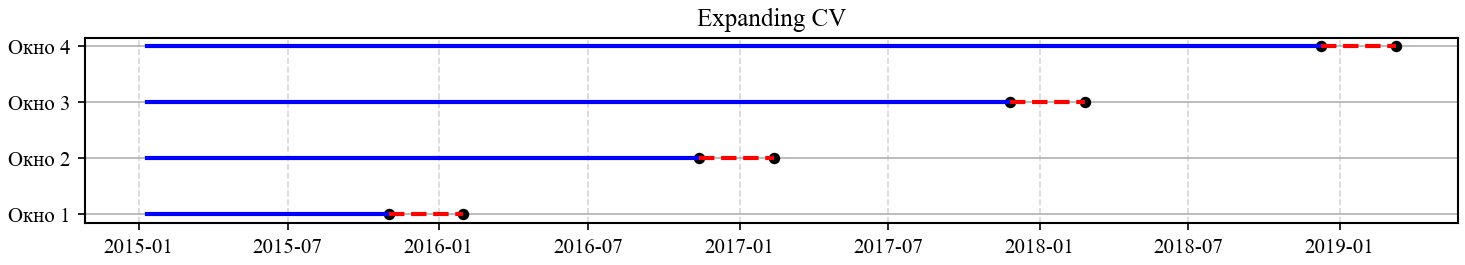

In [305]:
plot_cv_windows(df_uid, 'Consumption', cutoffs, h=13, title="Expanding CV")

Мы рассмотрели стратеги CV  с раширяющимся окном. В целом стратегии спилата окон [могут быть и другими]( https://joaquinamatrodrigo.github.io/skforecast/0.11.0/user_guides/backtesting.html).

На практике также стратегия сплита должны выбираться так, чтобы [соответствовать задаче](https://dl.leima.is/time-series/timeseries-evaluation.forecasting/). Например, в ряде случаев окно валидации должно опережать окно теста так, чтобы мы могли симулировать процесс в котором накопление данных значительно медленней появления новых данных. Или же например, в случае моделей глубокого обучения окно должно всегда быть фиксированного размера. Также  в некоторых случая - длинных ВР, отдельны интерес может представлять бектест для отдельных паттернов. В этом случае полезным будет использование нескольких стратегий спилат окна.


Отметим также, что при помощи процедуры `backtest` может быть построена процедура автоматизированногог сравнения моделей предсказания [`benchmarking`](https://github.com/sktime/sktime/blob/main/examples/04_benchmarking_v2.ipynb).

Отметим также, что на практике [выбор метрики](https://unit8co.github.io/darts/generated_api/darts.metrics.metrics.html#) или [метрик](https://auto.gluon.ai/stable/tutorials/timeseries/forecasting-metrics.html) для сравнения ВР это не тривиальный вопрос. Метрики могут быть разделены [на несколько классов](https://dl.leima.is/time-series/timeseries-metrics.forecasting/) при этом каждая из [метрик](https://otexts.com/fpp3/accuracy.html) будует иметь свою [интерпретацию](https://www.mdsi.tum.de/fileadmin/w00cet/di-lab/pdf/Amazon_SS2022_Final_Report.pdf). 

>Также отметим, что в ряде случаев верной оценкой точности на прогнозе было бы использование т.н. [__динамического прогноза__](https://timeweb.cloud/tutorials/python/prognozirovanie-vremennyh-ryadov-python-3#dinamicheskij-prognoz). Т.е. такого, когда следующие значения предсказанной величины строятся на результатах предсказания ее предыдущих значений а не на исходных тестовых данных. В противовес этому тестирование на выборке исходных данных может быть названо [__статическим прогнозом__](https://timeweb.cloud/tutorials/python/prognozirovanie-vremennyh-ryadov-python-3#staticheskij-prognoz).





## Построение вероятностных прогнозов моделей

Помимо процедуры `backtesting` валидация моделей может быть проведена несколькими способами:
1. Путем оценки/исследования остатков модели для предсказания ей тренировочного/валидационного набора данных.
2. Путем оценки моделей при помощи информационных критериев. Этим методом можно пользоваться для параметрических методов. При этом используются мини-максные [информационные критерии](https://bookdown.org/mpfoley1973/time-series/regression.html), которые в том числе были рассмотрены в работе <tt>ARIMA</tt>. В общем случае критерии формулируются, например, как:
$$AIC = N \log\left(\frac{SSE}{N}\right) + 2(k + 2),$$
где $N$ - объем выборки, $SSE$ - сумма квадратов ошибок, $k$ - общее число параметров модели.
3. Путем оценки вероятностных метрик - то есть того в каком диапазоне значений модель допускает появления реальных значений.


Типичные реализации прогнозирования, которые мы рассматривали прежде [являются точечными](https://www.lokad.com/probabilistic-forecasting-definition/). То есть предсказывают одно значение для одного шага прогноза. Такое поведение модели явялется нормальным. Однако,  в ряде случаев помимо самого значения прогноза требуется знание каких то [статистческих характеристик прогноза](https://otexts.com/fpp3/prediction-intervals.html). В наиболее полном случае требуется знание распределения результатов прогноза для каждой точки. Такой прогноз [называется  вероятностным](https://www.lokad.com/tv/2022/3/2/probabilistic-forecasting-for-supply-chain/). 

Другими словами вероятностный прогноз содержит набор вероятностей, связанных со всеми возможными будущими исходами для каждой точки прогноза. В противовес этому точечный прогноз указывает на один конкретный исход в качестве "прогноза". 

Вероятностные прогнозы важны, когда неопределенность прогназирования значема и неустранима Факторы неопределнности прогноза почти всегда имеет место в сложных системах. Например, для цепочек поставок вероятностные прогнозы необходимы для принятия надежных решений в условиях неопределенности будущего. В частности, спрос и время выполнения заказа - два ключевых аспекта анализа цепочки поставок - лучше всего учитывать с помощью вероятностного прогнозирования. Вероятностная перспектива естественным образом способствует экономической приоритезации решений на основе их ожидаемой, но неопределенной отдачи. 

Важно отметить, что не все методы прогноза допускают вероятностное прогназирование. Более того для оценки точности вероятностного прогноза требуются специальные метрики, которые отличаются от детерминированных аналогов. А также для использования вероятностных прогнозов требуется специализированный инструментарий, отличающийся от детерминированных аналогов.

И так, [Вероятностное прогнозирование обобщает](https://www.lokad.com/probabilistic-forecasting-definition/) то, что известно о будущих событиях, или мнения о них. В отличие от прогнозов с одним значением (point forecast) (например, прогнозов о том, что максимальная температура в данном месте в данный день составит 23 градуса Цельсия или что результатом данного футбольного матча будет безголевая ничья), вероятностные прогнозы присваивают вероятность каждому из нескольких различных исходов, а полный набор вероятностей представляет собой вероятностный прогноз (Probabilistic Forecasting). Другими словами в таким прогнозе мы предсказываем интервал значений, ассоциирующийся с неопределенностью предсказания (prediction intervals, Интервал прогнозирования - это диапазон значений, которые прогноз может принимать с заданной вероятностью.
<!-- Probabilistic forecasting summarizes what is known about, or opinions about, future events. In contrast to single-valued forecasts (such as forecasting that the maximum temperature at a given site on a given day will be 23 degrees Celsius, or that the result in a given football match will be a no-score draw), probabilistic forecasts assign a probability to each of a number of different outcomes, and the complete set of probabilities represents a probability forecast. In other words, in such a prediction, we predict an interval of values associated with the prediction uncertainty 

 A prediction interval is a range of values that the forecast can take with a given probability.



В общем случае Результаты вероятностного прогнозирования [могут быть](https://www.sktime.net/en/latest/examples/01b_forecasting_proba.html): 
* интервалы - `predict_interval(fh=None, X=None, coverage=0.90)`
* квантили - `predict_quantiles(fh=None, X=None, alpha=[0.05, 0.95])`
* диспрсия - `predict_var(fh=None, X=None, cov=False)`
* распределение - `predict_proba(fh=None, X=None, marginal=True)`

Примечания:
* у разных прогнозистов разные возможности! Также метрики, оценка и настройка различаются по "типу прогноза".
* Вероятностный прогноз может меняться от типасоставных шагов Пример: бутстрап

Заметим, $95\%$-ный интервал прогноза должен содержать диапазон значений, включающий фактическое будущее значение с вероятностью $95\%$. Тогда Вероятностное прогнозирование нацелено на получение полного прогнозного распределения. Точечное прогнозирование, с другой стороны, обычно возвращает среднее значение, медиану или другую точечную меру указанного распределения. Однако в реальных сценариях лучше прогнозировать не только наиболее вероятный будущий результат, но и множество альтернативных исходов.

<blockquote>
Формальный вид прогноза (эндогенный, одна временная метка прогноза):
* Пусть $y(t_1), \dots, y(t_n)$ - это наблюдения в фиксированные моменты времени $t_1, \dots, t_n$.
(мы рассматриваем $y$ как $\mathbb{R}^n$-значную случайную величину).
* Пусть $y'$ - это (истинное) значение, которое будет наблюдаться в будущий момент времени $\tau$.
(мы рассматриваем $y'$ как $\mathbb{R}$-значную случайную величину)

Более формальные детали и интуиция:

* __"точечный прогноз"__ - это предсказание/оценка условного ожидания $E[y'|y]$, где $y'$ - истинный результат. Интуиция: "из множества повторений/разных попыток предсказания - результат значение средним арифметическим значением".

* __"дисперсионный прогноз"__ (`predict_var(fh=None, X=None, cov=False)`) - это предсказание/оценка условного ожидания дисперсии $Var[y'|y]$. Интуиция: "из множества повторений - это значение является средним квадратичным расстоянием от наблюдения до идеального точечного прогноза".

* __"квантильный прогноз"__(`predict_quantiles(fh=None, X=None, alpha=[0.05, 0.95])`), в точке квантиля $\alpha \in (0,1)$ - это предсказание/оценка $\alpha$-квантиля $y'|y$, т.е. $F^{-1}_{y'|y}(\alpha)$, где $F^{-1}$  это (обобщенная) обратная `CDF` = квантильная функция случайной величины $y'|y$. Интуиция: "Из множества повторений вероятность появления данного будет равна или меньше  значения $\alpha$".
 
* __"Интервальный прогноз"__ или __"интервал предсказания"__ (`predict_interval(fh=None, X=None, coverage=0.90)`) с (симметричным) охватом $c \in (0,1)$ - это пара прогноз/оценка с нижней границей $a$ и верхней границей $b$, такая, что $P(\alpha \le y' \ge b|y)=c$ и $P(y'>b|y)=P(y<a|y)=(1-c)/2$. Интуиция: "Из множества повторений результат будет содержаться в интервале $[a,b]$  с вероятностью $c$. Причем вероятность того, что будут результаты выше равна вероятности того, что  будут результаты ниже".

* __"прогноз распределения"__ или __"полный вероятностный прогноз"__ (`predict_proba(fh=None, X=None, marginal=True)`)- это предсказание/оценка распределения $y'|y$ например, "это нормальное распределение со средним 42 и дисперсией 1". Интуиция: исчерпывающее описание механизма порождения множества повторений.

<!-- Примечания:
* _нижняя/верхняя часть интервальных прогнозов_ - это квантильные прогнозы в точках квантилей $0,5 - c/2$ и $0,5 + c/2$ (при условии, что распределения прогнозов абсолютно непрерывны).
* все остальные прогнозы могут быть получены из полного вероятностного прогноза; полный вероятностный прогноз может быть получен из всех квантильных или всех интервальных прогнозов.
* не существует точной зависимости между другими типами прогнозов (точечный или дисперсионный vs квантильный)
* в частности, точечный прогноз не обязательно должен быть медианным прогнозом aka 0,5-квантильным прогнозом. Это может быть 
$\alpha$-quantile для любого $\alpha$! -->
<!-- 
Частая путаница в литературе и пакетах python: * охват 'c' vs квантиль '\alpha' * охват 'c' vs значимость 'p = 1-c' * квантиль нижней границы интервала, 'p/2', vs 'p' * интервальные прогнозы vs связанные, но существенно разные понятия: доверительный интервал для прогнозируемого среднего; байесовский апостериор или интервал доверия для прогнозируемого среднего * все прогнозы выше могут быть байесовскими, путаница: "апостериоры разные" или "должны оцениваться по-разному". -->



<!-- Formal view (endogeneous, one forecast time stamp):

Let $y(t_1), \dots, y(t_n)$ be observations at fixed time stamps $t_1, \dots, t_n$.

(we consider $y$ as an $\mathbb{R}^n$-valued random variable)

Let $y'$ be a (true) value, which will be observed at a future time stamp $\tau$.

(we consider $y'$ as an $\mathbb{R}$-valued random variable)

More formal details & intuition:
* a “point forecast” is a prediction/estimate of the conditional expectation $E[y'|y]$ where $y'$ is a true result.
. Intuition: “out of many repetitions/differnt attempts to forecast, this value is the arithmetic average of all observations”.
* a “variance forecast” ('predict_var(fh=None, X=None, cov=False)')  is a prediction/estimate of the conditional expectation $Var[y'|y]$ 
. Intuition: “out of many repetitions/worlds, this value is the average squared distance of the observation to the perfect point forecast”.
* a “quantile forecast”, at quantile point  $\alpha \in (0,1)$ is a prediction/estimate of the 
$\alpha$-quantile of $y'|y$, i.e., of $F^{-1}_{y'|y}(\alpha)$, where $F^{-1}$
 is the (generalized) inverse cdf = quantile function of the random variable $y'|y$. 
 Intuition: “out of many repetitions/worlds, a fraction of exactly 
 will have equal or smaller than this value.”
* an “interval forecast” or “predictive interval” with (symmetric) coverage $c \in (0,1)$ is a prediction/estimate pair of lower bound $a$ and upper bound 
$b$ such that $P(\alpha \le y' \ge b|y)=c$
and $P(y'>b|y)=P(y<a|y)=(1-c)/2$. Intuition: “out of many repetitions/worlds, a fraction of exactly $c$
will be contained in the interval $[a,b]$, and being above is equally likely as being below”.
* a “distribution forecast” or “full probabilistic forecast” is a prediction/estimate of the distribution of $y'|y$
, e.g., “it’s a normal distribution with mean 42 and variance 1”. Intuition: exhaustive description of the generating mechanism of many repetitions/worlds.

Notes:

* lower/upper of interval forecasts are quantile forecasts at quantile points  $0.5 - c/2$
 and $0.5 + c/2$
 (as long as forecast distributions are absolutely continuous).
* all other forecasts can be obtained from a full probabilistic forecasts; a full probabilistic forecast can be obtained from all quantile forecasts or all interval forecasts.
* there is no exact relation between the other types of forecasts (point or variance vs quantile)
* in particular, point forecast does not need to be median forecast aka 0.5-quantile forecast. Can be 
$\alpha$-quantile for any $\alpha$!

Frequent confusion in literature & python packages: * coverage 'c' vs quantile '\alpha' * coverage 'c' vs significance 'p = 1-c' * quantile of lower interval bound, 'p/2', vs 'p' * interval forecasts vs related, but substantially different concepts: confidence interval on predictive mean; Bayesian posterior or credibility interval of the predictive mean * all forecasts above can be Bayesian, confusion: “posteriors are different” or “have to be evaluted differently”

 -->


Технически существует [множество способов](https://cienciadedatos.net/documentos/py42-forecasting-prediction-intervals-machine-learning.html) оценки интервалов прогнозирования. Способы можно разделить на специфические для моделей (например оценка дисперсии предсказывается в процессе оценки коэффициентов [<tt>ARIMA</tt>](https://otexts.com/fpp2/arima-forecasting.html#prediction-intervals-3) или [для наивных предсказаний](https://otexts.com/fpp2/prediction-intervals.html#benchmark-methods)) и т.н. независимые от модели способы. Важно понимать что большинство способов требуют, чтобы остатки (ошибки) модели следовали [нормальному распределению](https://otexts.com/fpp3/prediction-intervals.html). 
Когда это свойство не предполагается, обычно используются несколько альтернатив: 
* Интервалы прогнозирования на основе бутстрепных остатков и [рекурсивно-многошагового прогноза](https://skforecast.org/0.5.0/user_guides/autoregresive-forecaster.html).
<img src="https://skforecast.org/0.5.0/img/diagram-recursive-mutistep-forecasting.png" alt="" style="width:500px;">
* Интервалы прогнозирования на основе квантильной регрессии и [прямого многошагового прогноза](https://skforecast.org/0.5.0/user_guides/direct-multi-step-forecasting.html).
<img src="https://skforecast.org/0.5.0/img/diagram-direct-multi-step-forecasting.png" alt="" style="width:500px;">
* Интервалы прогнозирование с использованием техники [bootstrap](https://skforecast.org/0.5.0/user_guides/prediction-intervals). При этом на каждой точке горизонта вычисляются значения нужных процентилей (квантилей).
<img src="https://skforecast.org/0.5.0/img/diagram-bootstrapping-prediction-intervals.png" style="width:500px;">
* С использованием квантильной регресии (оценка интервалов).
* Методы т.н. [конформного предсказация](https://algotrading101.com/learn/conformal-prediction-guide/). В методе предлагается задаться оценкой разрброса и определить число предсказаний, которые туда попадают.

>[Интересно также отметить](https://robjhyndman.com/hyndsight/narrow-pi/), что  почти все интервалы прогнозирования слишком узкие. Например, номинальные 95 %-ные интервалы могут обеспечивать охват только от 71 до 87 % возможных значений прогнозов. Это хорошо известное явление, которое возникает потому, что модель распределения не учитывают все источники неопределенности. В моделях прогнозирования существует как минимум четыре источника неопределенности:
> * случайный член ошибки
> * Оценки параметров
> * Выбор модели для исторических данных
> * Продолжение процесса генерирования исторических данных в будущем.
>
> При построении интервалов прогнозирования для моделей временных рядов обычно учитывается только первый из этих источников. Поэтому целесообразно использовать тестовые данные для проверки эмпирического покрытия интервала, а не полагаться только на ожидаемое значение.

<!-- Let us note that technuically there are multiple ways to estimate prediction intervals, most of which require that the residuals (errors) of the model follow a normal distribution. When this property cannot be assumed, two alternatives commonly used are 
* Prediction intervals based on bootstrapped residuals and [recursive-multi-step forecaster](https://skforecast.org/0.5.0/user_guides/autoregresive-forecaster.html).
* Prediction intervals based on quantile regression and [direct-multi-step forecaster](https://skforecast.org/0.5.0/user_guides/direct-multi-step-forecasting.html). https://cienciadedatos.net/documentos/py42-forecasting-prediction-intervals-machine-learning.html

Interesting to note that 
in real-world problems, almost all prediction intervals are too narrow. For example, nominal 95% intervals may only provide coverage between 71% and 87%. This is a well-known phenomenon and arises because they do not account for all sources of uncertainty. With forecasting models, there are at least four sources of uncertainty:
The random error term
The parameter estimates
The choice of model for the historical data
The continuation of the historical data generating process into the future
When producing prediction intervals for time series models, generally only the first of these sources is taken into account. Therefore, it is advisable to use test data to validate the empirical coverage of the interval and not only rely on the expected one.
https://robjhyndman.com/hyndsight/narrow-pi/-->


Отметим еще раз важность прогнозирования интервалов предсказания [(доверительных интервалов) во временных рядах](https://nixtlaverse.nixtla.io/mlforecast/docs/tutorials/prediction_intervals_in_forecasting_models.html#importance-of-confidence-interval-prediction-in-time-series):
* __Оценка неопределенности__: Доверительный интервал обеспечивает меру неопределенности, связанной с прогнозами временных рядов. Он позволяет количественно оценить изменчивость и диапазон разборса возможных будущих значений, что очень важно для принятия обоснованных решений.
* __Оценка точности__: Имея доверительный интервал, можно оценить надежность прогнозов. Если интервал узкий, это говорит о том, что прогноз более точный и надежный. С другой стороны, если интервал широкий, это указывает на большую неопределенность и меньшую точность прогноза.
* __Управление рисками__: Доверительный интервал помогает в управлении рисками, предоставляя информацию о возможных сценариях будущего. Он позволяет определить диапазоны, в которых могут находиться реальные значения, и принимать решения на основе этих возможных сценариев.
* __Эффективная коммуникация__: Доверительный интервал - полезный инструмент для четкой и точной передачи прогнозов. Он позволяет донести до заинтересованных сторон изменчивость и неопределенность, связанную с прогнозами, избегая неправильной или слишком оптимистичной интерпретации результатов.

Поэтому прогнозирование доверительных интервалов во временных рядах необходимо для понимания и управления неопределенностью, оценки точности прогнозов и принятия обоснованных решений на основе возможных сценариев будущего.

>Большинство моделей временных рядов генерируют прогнозы, которые следуют нормальному распределению, что подразумевает, что мы предполагаем, что возможные будущие значения следуют нормальному распределению. Однако, реальное распределение не всегда такое.

### Покрытие интервала predict_interval

Как уже было замечено вероятностное прогназирование часто используется для двух процедур:
* [процедура `backtest`](https://joaquinamatrodrigo.github.io/skforecast/0.8.1/user_guides/backtesting.html) в качестве допонительной меры отбора моделей и настройки их параметров.
* [допонительные метрики](https://auto.gluon.ai/stable/tutorials/timeseries/forecasting-metrics.html) оценки для будущих значений при настройки моделей. В том числе как мера оценки [интервала разброса значений оценки](https://otexts.com/fpp3/prediction-intervals.html). Такие метрики могут помочь и дополнить процедуру evaluation. Каждая из метрик будет иметь [свою интерпретацию](https://otexts.com/fpp3/distaccuracy.html).

Одним из важных свойств вероятностного предсказания является возможность введения [дополнительных метрик](https://www.sktime.net/en/latest/examples/01b_forecasting_proba.html#overview---theory), позволяющих корректировать прогноз.

Мы ожидаем, что прогнозируемое `y` имеет форму, отличную от истинного `y`, поэтому метрики имеют вид

`metric(y_true: series, y_pred: proba_prediction) -> float`.

где `proba_prediction` - тип конкретного "типа вероятностного предсказания".

## Дополнительно про CV

In [226]:
def make_cv_splits(
    df, 
    h, 
    step_size, 
    train_window=None, 
    strategy='expanding',
    n_windows_per_train=1,
    test_step=None  # ← НОВЫЙ ПАРАМЕТР
):
    """
    Генерирует CV-окна.
    
    Новые параметры:
    - n_windows_per_train: сколько тестовых окон на каждую позицию обучения.
    - test_step: шаг между тестовыми окнами (в шагах временной шкалы).
                 Если None → равен h (тесты идут подряд без пропусков).
    """
    if test_step is None:
        test_step = h
    
    df = df.sort_values(['unique_id', 'ds'])
    all_splits = []
    
    for uid, group in df.groupby('unique_id'):
        dates = group['ds'].tolist()
        n = len(dates)
        
        if strategy == 'backtest':
            if train_window is None:
                raise ValueError("Для backtest нужен train_window")
            train_start_idx = 0
            train_end_idx = train_window - 1
            
            # Первая позиция теста
            base_test_start = train_end_idx + 1
            pos = base_test_start
            
            while pos + h - 1 < n:
                for w in range(n_windows_per_train):
                    test_start = pos + w * test_step
                    test_end = test_start + h - 1
                    if test_end >= n:
                        break
                    all_splits.append({
                        'unique_id': uid,
                        'train_start': dates[train_start_idx],
                        'train_end': dates[train_end_idx],
                        'test_start': dates[test_start],
                        'test_end': dates[test_end]
                    })
                # Сдвигаемся к следующей позиции обучения
                pos += step_size
                
        else:
            # expanding / sliding
            # Последняя возможная позиция cutoff'а
            last_possible = n - 1 - (n_windows_per_train - 1) * test_step - h
            if last_possible < 0:
                continue
                
            cutoff_positions = []
            pos = last_possible
            min_train_len = train_window if strategy == 'sliding' else 1
            
            while pos >= min_train_len - 1:
                cutoff_positions.append(pos)
                pos -= step_size
            cutoff_positions = sorted(cutoff_positions)
            
            for cutoff in cutoff_positions:
                if strategy == 'expanding':
                    train_start_idx = 0
                else:  # sliding
                    train_start_idx = max(0, cutoff - train_window + 1)
                
                for w in range(n_windows_per_train):
                    test_start = cutoff + 1 + w * test_step
                    test_end = test_start + h - 1
                    if test_end >= n:
                        break
                    all_splits.append({
                        'unique_id': uid,
                        'train_start': dates[train_start_idx],
                        'train_end': dates[cutoff],
                        'test_start': dates[test_start],
                        'test_end': dates[test_end]
                    })
    
    return pd.DataFrame(all_splits)

In [227]:
def plot_cv_splits(df, splits, unique_id, title="CV Splits"):
    """
    Визуализация CV-окон линиями.
    
    Параметры:
    - df: исходный DataFrame с ['ds', 'y']
    - splits: результат make_cv_splits
    - unique_id: строка
    - title: заголовок
    """
    series = df[df['unique_id'] == unique_id].sort_values('ds')
    windows = splits[splits['unique_id'] == unique_id]
    
    plt.figure(figsize=(10, 2 + len(windows) * 0.5))
    
    for i, (_, row) in enumerate(windows.iterrows()):
        y_level = i + 1
        
        # Обучение
        plt.plot([row['train_start'], row['train_end']], [y_level, y_level],
                 color='C0', linewidth=2, solid_capstyle='butt')
        # Тест
        plt.plot([row['test_start'], row['test_end']], [y_level, y_level],
                 color='C1', linestyle='--', linewidth=2, solid_capstyle='butt')
        # Граница
        plt.scatter([row['train_end']], [y_level], color='black', s=20, zorder=5)
    
    plt.yticks(range(1, len(windows) + 1), [f"Окно {i+1}" for i in range(len(windows))])
    plt.xlabel('Дата')
    plt.title(f"{title}: {unique_id}")
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [230]:
splits_exp

,unique_id,train_start,train_end,test_start,test_end
0,Consumption,2015-01-11,2015-11-01,2015-11-08,2016-11-13
1,Consumption,2015-01-11,2016-11-13,2016-11-20,2017-11-26
2,Consumption,2015-01-11,2017-11-26,2017-12-03,2018-12-09
3,Consumption,2015-01-11,2018-12-09,2018-12-16,2019-12-22
4,Solar,2015-01-11,2015-11-01,2015-11-08,2016-11-13
5,Solar,2015-01-11,2016-11-13,2016-11-20,2017-11-26
6,Solar,2015-01-11,2017-11-26,2017-12-03,2018-12-09
7,Solar,2015-01-11,2018-12-09,2018-12-16,2019-12-22
8,Wind,2015-01-11,2015-11-01,2015-11-08,2016-11-13
9,Wind,2015-01-11,2016-11-13,2016-11-20,2017-11-26


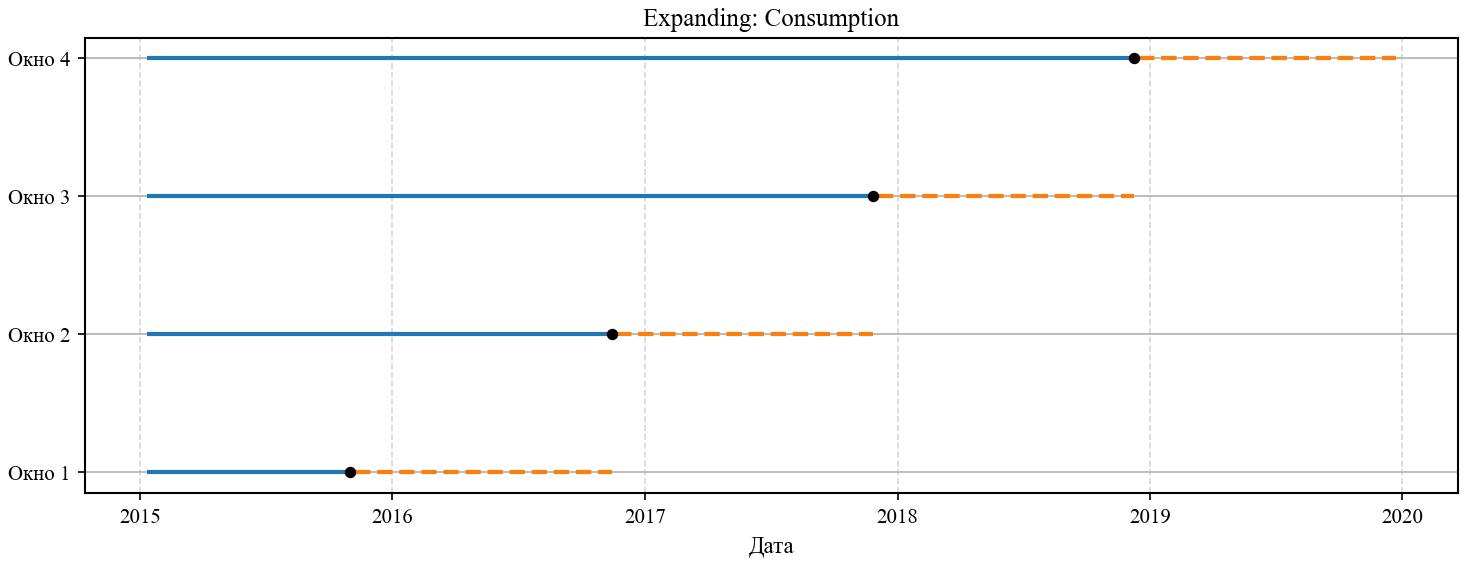

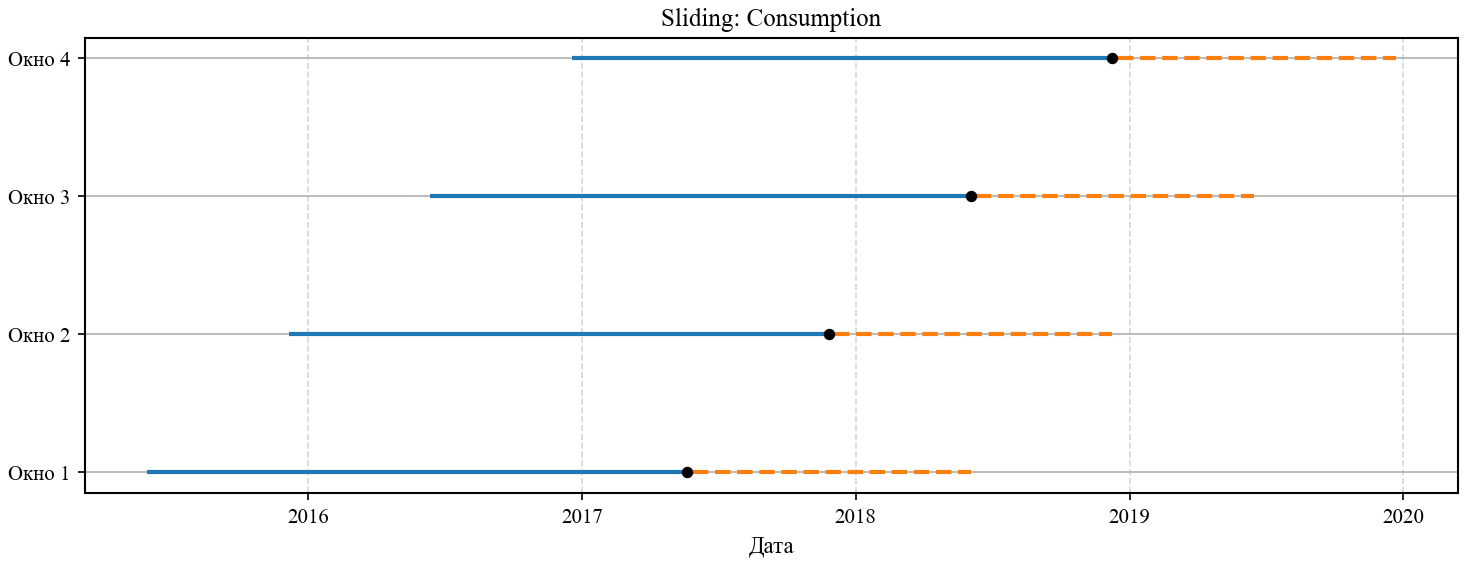

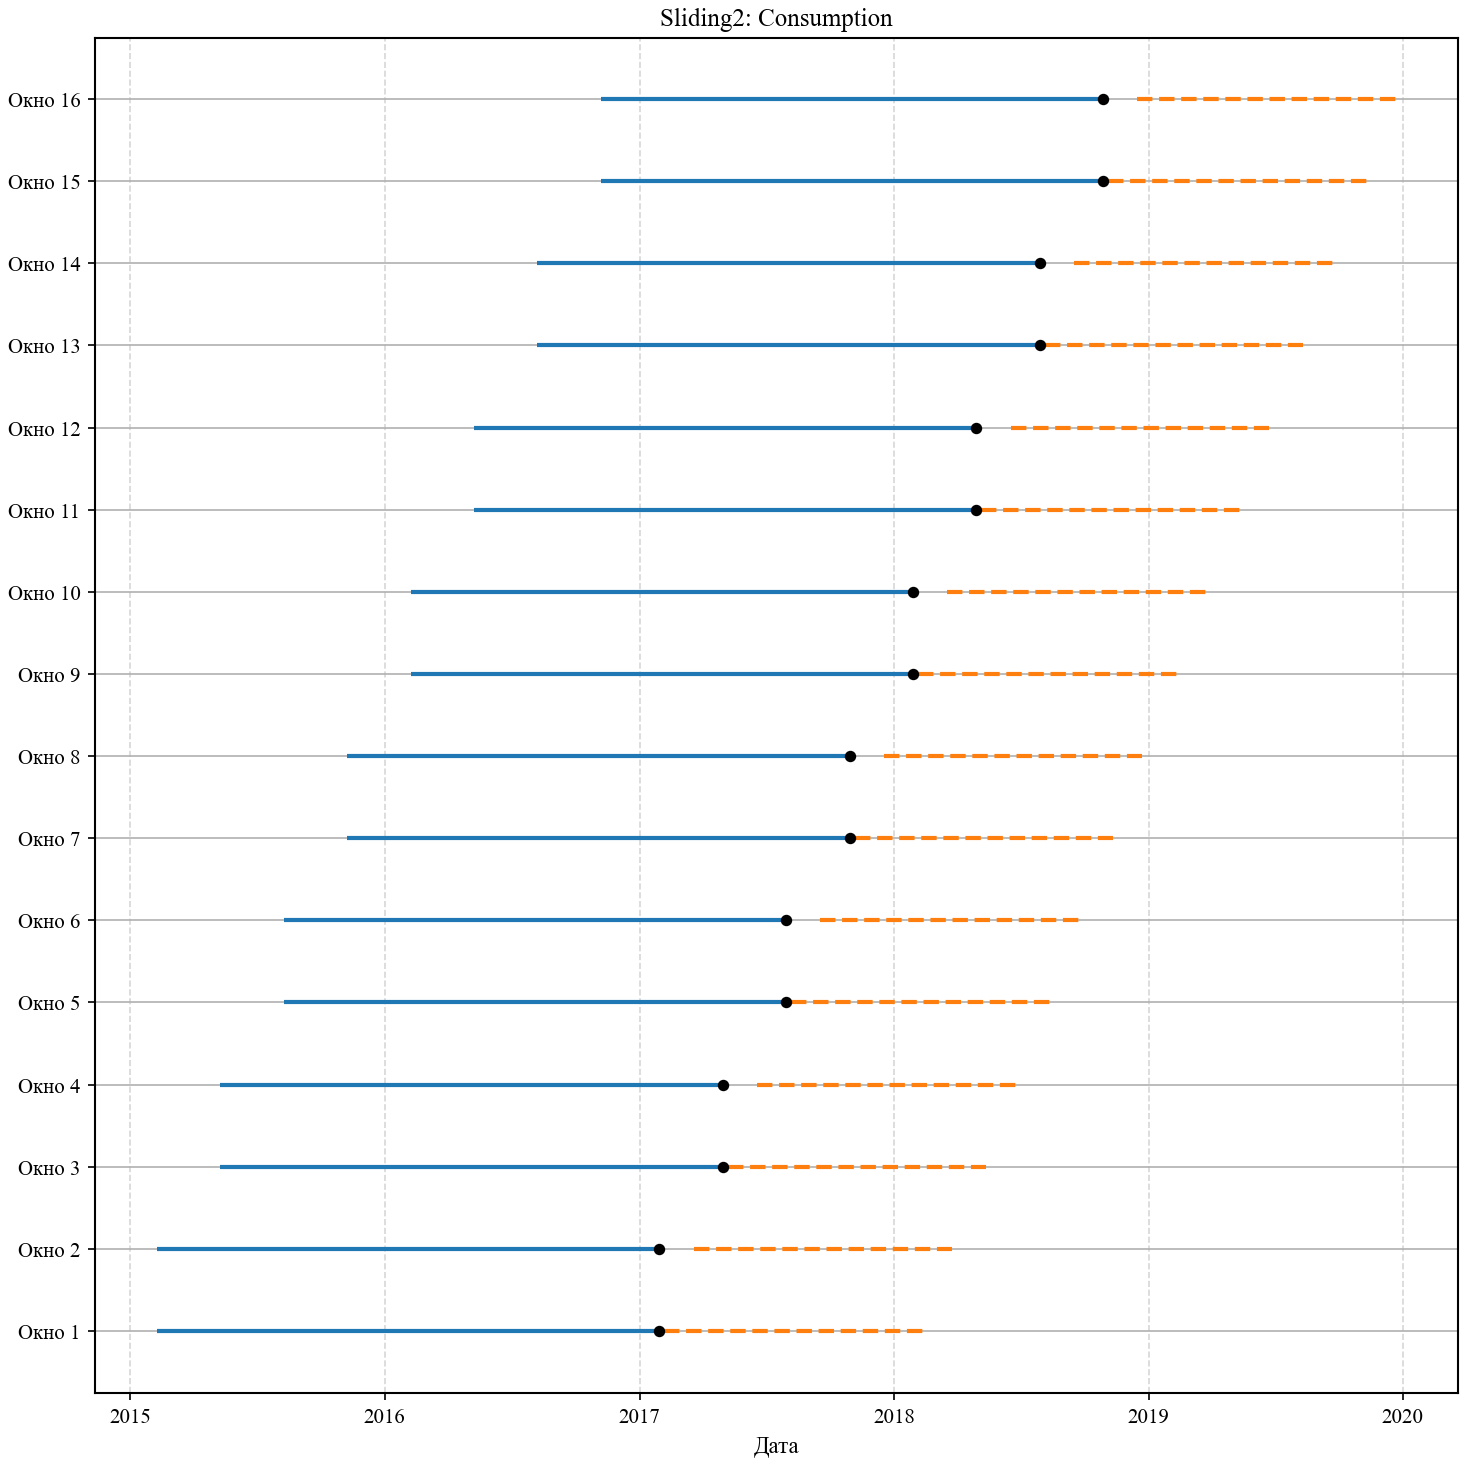

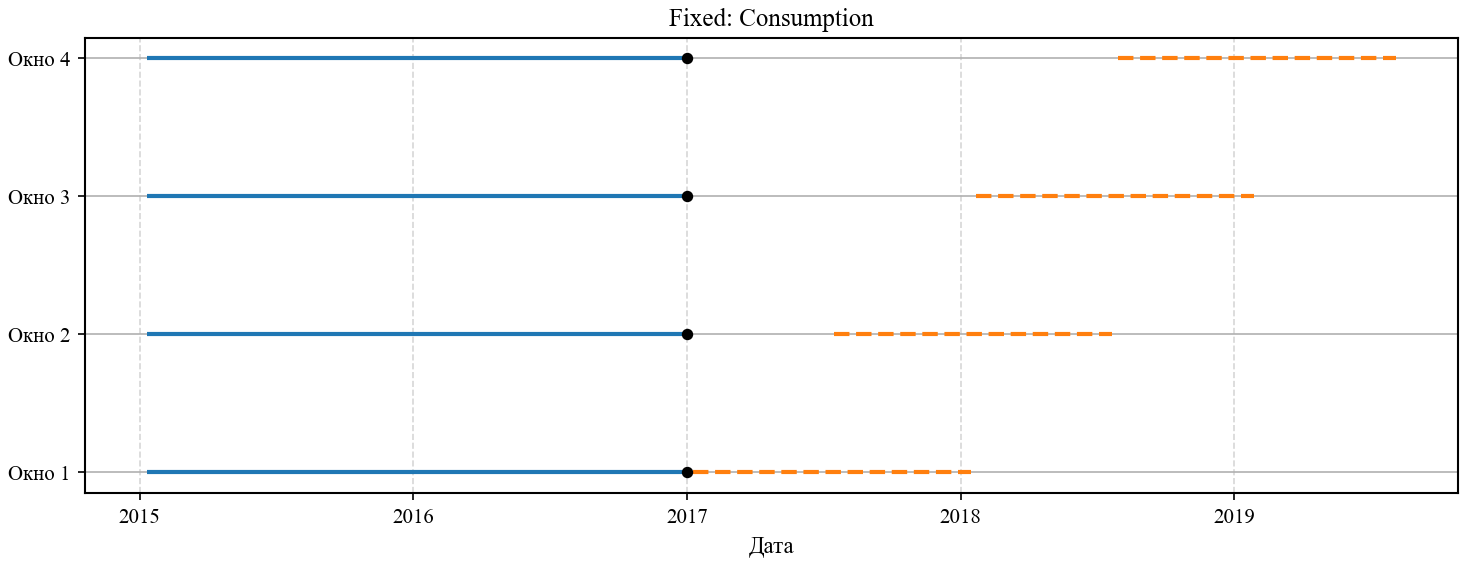

In [248]:
# Expanding
splits_exp = make_cv_splits(panel_df, h=FH//2, step_size=FH//2, strategy='expanding')
plot_cv_splits(panel_df, splits_exp, 'Consumption', 'Expanding')

# Sliding
splits_slid = make_cv_splits(panel_df, h=FH//2, step_size=FH//4, train_window=2*SEASON, strategy='sliding')
plot_cv_splits(panel_df, splits_slid, 'Consumption', 'Sliding')

# Sliding2
splits_slid2 = make_cv_splits(panel_df, h=FH//2, step_size=FH//8, train_window=2*SEASON, n_windows_per_train = 2, test_step = FH//16,  strategy='sliding')
plot_cv_splits(panel_df, splits_slid2, 'Consumption', 'Sliding2')

# Fixed (backtesting)
splits_fixed = make_cv_splits(panel_df,  h=FH//2, step_size=FH//4, train_window=2*SEASON, strategy='backtest')
plot_cv_splits(panel_df, splits_fixed, 'Consumption', 'Fixed')

In [ ]:
from utilsforecast.evaluation import evaluate

In [259]:
def cv_evaluation_with_forecasts(
    df, 
    splits, 
    models, 
    model_names,
    metrics,
    refit=True,
    freq=FREQ
):
    all_evals = []
    all_forecasts = []  # ← НОВОЕ
    sf_cache = {}
    
    grouped = splits.groupby(['unique_id', 'train_start', 'train_end'])
    
    for (uid, train_start, train_end), group in grouped:
        test_rows = []
        test_info = []  # чтобы знать, откуда какие даты
        for _, row in group.iterrows():
            mask = (
                (df['unique_id'] == uid) &
                (df['ds'] >= row['test_start']) &
                (df['ds'] <= row['test_end'])
            )
            subset = df[mask]
            test_rows.append(subset)
            test_info.append(row)
        
        if not test_rows:
            continue
            
        test = pd.concat(test_rows).sort_values('ds').reset_index(drop=True)
        train = df[
            (df['unique_id'] == uid) &
            (df['ds'] >= train_start) &
            (df['ds'] <= train_end)
        ].copy()
        
        if len(train) == 0 or len(test) == 0:
            continue
        
        pred_cols = {'ds': test['ds'].values, 'unique_id': uid}
        for model, name in zip(models, model_names):
            cache_key = (name, uid, train_start, train_end)
            if refit or cache_key not in sf_cache:
                sf = StatsForecast(models=[model], freq=freq)
                sf.fit(train)
                if not refit:
                    sf_cache[cache_key] = sf
            else:
                sf = sf_cache[cache_key]
            
            h = len(test)
            pred = sf.predict(h=h)
            pred_cols[name] = pred[name].values[:h]
        
        # Сохраняем прогнозы
        forecast_df = pd.DataFrame(pred_cols)
        forecast_df['train_start'] = train_start
        forecast_df['train_end'] = train_end
        all_forecasts.append(forecast_df)
        
        # Оценка
        eval_df = test[['unique_id', 'ds', 'y']].copy()
        for name in model_names:
            eval_df[name] = pred_cols[name]
        
        eval_result = evaluate(df=eval_df, metrics=metrics, train_df=train)
        eval_result['train_start'] = train_start
        eval_result['train_end'] = train_end
        eval_result['test_start'] = test['ds'].min()
        eval_result['test_end'] = test['ds'].max()
        all_evals.append(eval_result)
    
    return pd.concat(all_evals, ignore_index=True), pd.concat(all_forecasts, ignore_index=True)

In [260]:
results = cv_evaluation(
    df=panel_df,
    splits=splits_slid2,
    models=models,
    model_names=model_names,
    metrics=metrics,
    refit=True
)

# Сводка
summary = results.groupby(['metric','unique_id'])[model_names].agg(['mean', 'std'])
summary.round(4)

SeasESOpt              HW_Add         
                         mean      std       mean      std
metric unique_id                                          
mase   Consumption     2.9613   0.3672     2.9424   0.2973
       Solar           3.5460   0.3681     3.4722   0.2609
       Wind            1.2924   0.2149     1.2807   0.2227
rmse   Consumption   822.1785  46.8973   819.5732  62.1820
       Solar         611.1056  36.7977   592.4229  32.6120
       Wind         1399.2439  67.5437  1372.2755  97.0381
smape  Consumption     0.0345   0.0027     0.0341   0.0032
       Solar           0.3829   0.0451     0.3596   0.0298
       Wind            0.2669   0.0237     0.2470   0.0371